# CRAFTS and HI4PI HVC analysis

This notebook compares a user-prepared CRAFTS H I cutout with a matched HI4PI cutout, constructs moment and position-velocity diagnostics, and measures peak-velocity trends along three analysis tracks. The repository does not redistribute survey data. Download the public CRAFTS and HI4PI products and prepare the local files described in `README.md` before running the notebook.


## 1. Apply the SoFiA mask

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

import astropy.units as u
from astropy.utils.data import download_file
from astropy.io import fits  # We use fits to open the actual data file

from astropy.utils import data
data.conf.remote_timeout = 60

from spectral_cube import SpectralCube
 
#from astroquery.esasky import ESASky
#from astroquery.utils import TableList
from astropy.wcs import WCS
from reproject import reproject_interp
import pylab as pl
import numpy as np
from astropy.visualization import quantity_support
from astropy import units as u
from astropy import wcs

# set so that these display properly on black backgrounds
pl.rcParams['figure.facecolor']='w'

from spectral_cube import SpectralCube

from pvextractor import extract_pv_slice, Path
from spectral_cube import SpectralCube, BooleanArrayMask

/Users/macx/Documents/Codex/2026-08-19/https-github-com-astroyxyxyx-hvc-https/work/HVC/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
# Read the FITS mask produced after source masking.
masked_fits = fits.open('./CRAFTS_-4.7_-350_-150_baseline_Jy_mask.fits')
mask_data = masked_fits[0].data.astype(bool)  # Two-dimensional mask data.
mask_wcs = WCS(masked_fits[0].header)

# Read the unmasked three-dimensional spectral cube.
cube = SpectralCube.read('./CRAFTS_-4.7_-350_-150_baseline.fits_Jy.fits')


In [41]:
print("Mask WCS:", mask_wcs)
print("Cube WCS:", cube.wcs)

Mask WCS: WCS Keywords

Number of WCS axes: 3
CTYPE : 'RA---CAR' 'DEC--CAR' 'VOPT' 
CRVAL : 359.9875 0.0 599954.3363740001 
CRPIX : -127.0 276.5 -3725.0 
PC1_1 PC1_2 PC1_3  : 1.0 0.0 0.0 
PC2_1 PC2_2 PC2_3  : 0.0 1.0 0.0 
PC3_1 PC3_2 PC3_3  : 0.0 0.0 1.0 
CDELT : -0.025 0.025 -201.283594733 
NAXIS : 153  89  994
Cube WCS: WCS Keywords

Number of WCS axes: 3
CTYPE : 'RA---CAR' 'DEC--CAR' 'VOPT' 
CRVAL : 359.9875 0.0 599954.336374 
CRPIX : -127.0 276.5 -3725.0 
PC1_1 PC1_2 PC1_3  : 1.0 0.0 0.0 
PC2_1 PC2_2 PC2_3  : 0.0 1.0 0.0 
PC3_1 PC3_2 PC3_3  : 0.0 0.0 1.0 
CDELT : -0.025 0.025 -201.283594733 
NAXIS : 153  89  994


In [42]:
mask = BooleanArrayMask(mask=mask_data, wcs=mask_wcs)

In [43]:
masked_cube = cube.with_mask(mask, wcs_tolerance=1e-2) 

In [46]:
# Save the masked cube.
# SpectralCube.write preserves the cube WCS and unit metadata.
masked_cube.write(
    './CRAFTS_-4.7_-350_-150_baseline.fits_Jy---mask.fits',
    overwrite=True
)

### Convert Jy/beam to K

In [47]:
from radio_beam import Beam
with fits.open('./CRAFTS_-4.7_-350_-150_baseline.fits_Jy---mask.fits', mode='update') as hdul: # Inspect and update the FITS header. 
    header = hdul[0].header
    print(header)
    header['BEAM']='Beam: BMAJ=240 arcsec BMIN=240 arcsec &' 
    header['BMAJ']    =               0.066666667                                                  
    header['BMIN']    =               0.066666667
    header['RESTFRQ'] =        1420405751.77                      
    hdul.flush()

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -32 / array data type                                NAXIS   =                    3 / number of array dimensions                     NAXIS1  =                  153                                                  NAXIS2  =                   89                                                  NAXIS3  =                  994                                                  DATE    = '2024-08-07'         / Creation UTC (CCCC-MM-DD) date of FITS header  COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    COMMENT Original Unit=m / s                                                     COMMENT Original Type=VOPT                                                      EPOCH   =              2000.00 /                                                BPA     =              0.00000 /        

In [48]:
from astropy import constants as const
# Define physical constants.
c = const.c.value  # Speed of light in vacuum, in m/s.
k = const.k_B.value  # Boltzmann constant, in J/K.

# Read the FITS cube in Jy/beam.
filename = './CRAFTS_-4.7_-350_-150_baseline.fits_Jy---mask.fits'  # Input FITS filename.
hdul = fits.open(filename)
data_jy_beam = hdul[0].data
header = hdul[0].header

# Read the required observing parameters from the FITS header.
restfrq = header['RESTFRQ']  # Rest frequency in Hz.
bmaj = header['BMAJ']  # Beam major-axis FWHM in degrees.
bmin = header['BMIN']  # Beam minor-axis FWHM in degrees.

# Calculate the observing wavelength.
lambda_ = c / restfrq

# Convert beam sizes from degrees to radians.
bmaj_rad = np.radians(bmaj)
bmin_rad = np.radians(bmin)

# Calculate the Gaussian beam solid angle.
omega = 1.133 * bmaj_rad * bmin_rad

# Convert the data from Jy/beam to brightness temperature in K.
# Rayleigh-Jeans conversion: T_b = (S_v * lambda^2) / (2 * k * Omega) * 1e-26.
data_k = (data_jy_beam * (lambda_**2)) / (2 * k * omega) * 1e-26

# Update the FITS unit keyword.
header['BUNIT'] = 'K'  # Set the output unit.

# Create a new primary HDU.
hdu = fits.PrimaryHDU(data=data_k, header=header)

# Save the converted FITS cube.
new_filename = './CRAFTS_-4.7_-350_-150_baseline_Jy_mask----mask-K.fits'  # Output filename.
hdu.writeto(new_filename, overwrite=True)

# Close the input FITS file.
hdul.close()

print(f"Converted the data from Jy/beam to K and saved the result as {new_filename}")
print(f"Converted data range: {np.nanmin(data_k):.3f} K to {np.nanmax(data_k):.3f} K")

已将单位从Jy/beam转换回K，并保存为 ./CRAFTS_-4.7_-350_-150_baseline_Jy_mask----mask_K.fits
转换后的数据范围: -2.724 K 到 2.343 K


## 2. Import analysis dependencies

Import the astronomy, numerical, and plotting libraries used throughout the
notebook. Input and output filenames are written explicitly in the cells that
consume or create each product so the workflow can be run directly from this
folder without machine-specific path configuration.

In [49]:

from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np
import warnings
import matplotlib.patches as patches
from astropy.io.fits.verify import VerifyWarning
from astropy.wcs import FITSFixedWarning

## 3. Plot the Magellanic-system context

Read the public HI4PI HVC column-density map, select the requested Galactic-coordinate field, and annotate the Magellanic Clouds, Stream sections, Leading Arm, analysis tracks, and the CRAFTS study region.

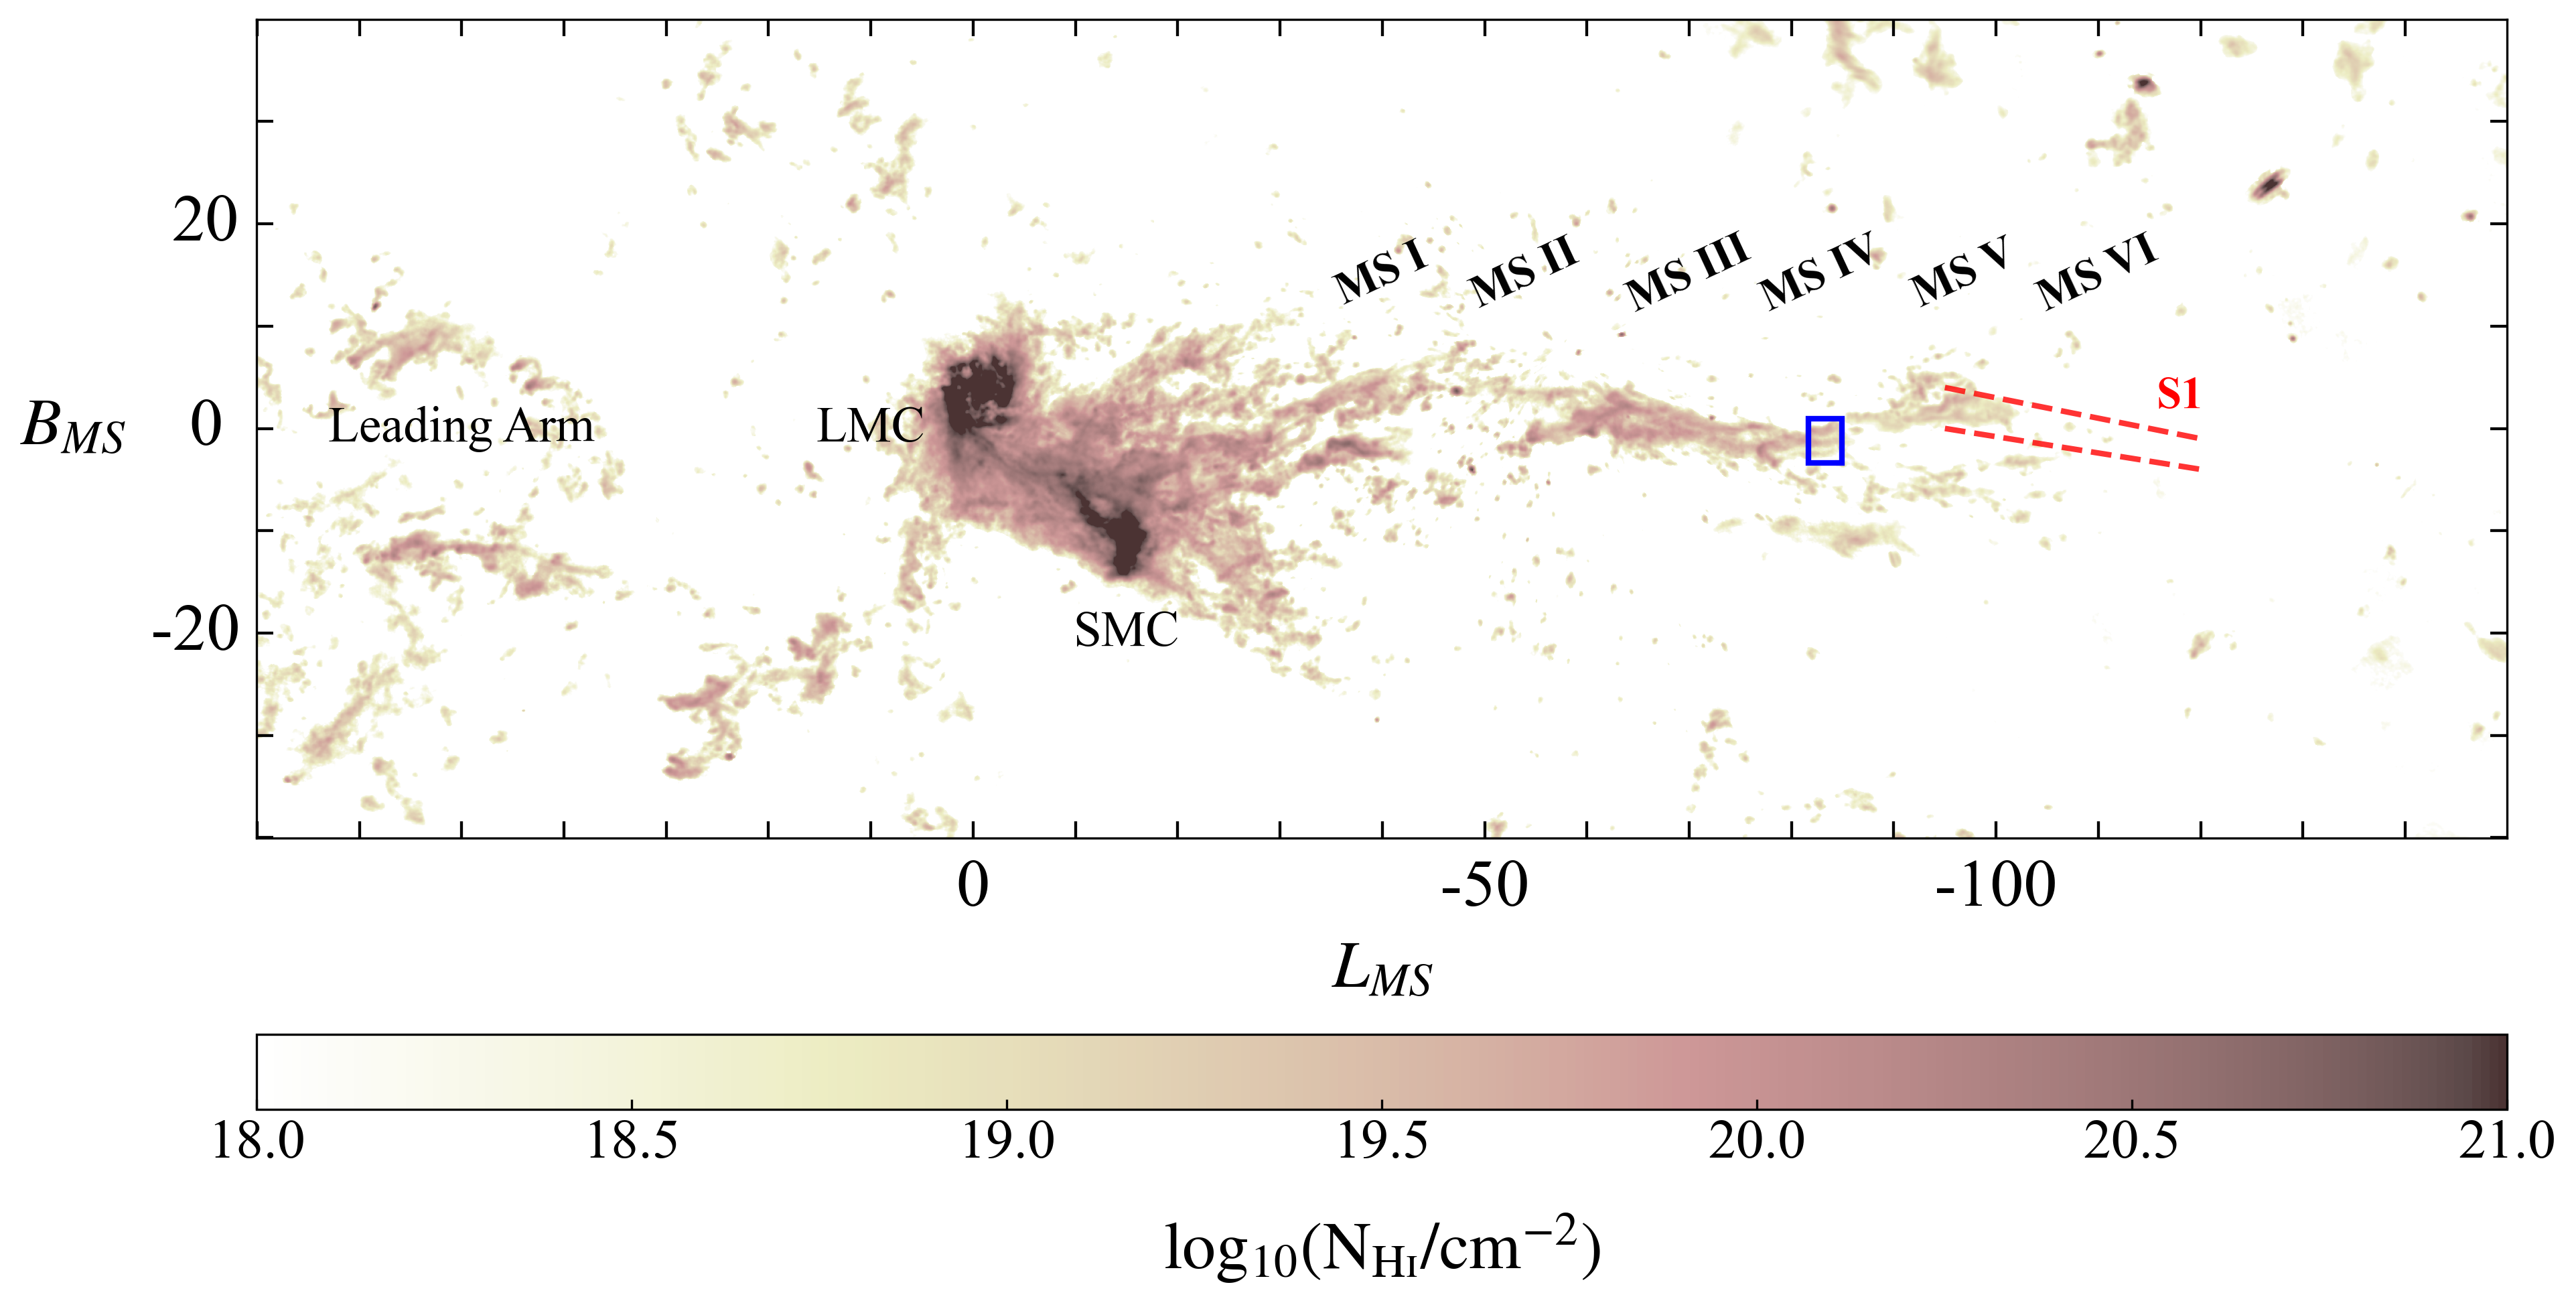

In [51]:

# Set the global font to Times New Roman.
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'  # Use STIX math fonts to match Times-style text.

# Suppress unrelated warnings.
warnings.filterwarnings('ignore', category=VerifyWarning)
warnings.filterwarnings('ignore', category=FITSFixedWarning)

# 1. Read FITS data and WCS.
hdu = fits.open("./hi4pi-hvc-nhi-mag-car.fits")[0]
wcs = WCS(hdu.header)

# 2. Define the target sky range: Galactic longitude 70-150 deg and latitude -40 to 40 deg.
lon_min, lon_max = 70, 210
lat_min, lat_max = -40, 40

# 3. Convert sky coordinates to pixel coordinates.
coord1 = SkyCoord(lon_min*u.deg, lat_min*u.deg, frame='galactic')
coord2 = SkyCoord(lon_max*u.deg, lat_max*u.deg, frame='galactic')
x1, y1 = wcs.world_to_pixel(coord1)
x2, y2 = wcs.world_to_pixel(coord2)

# 4. Handle pixel indices with integer conversion and boundary protection.
x_min, x_max = int(np.round(x1)), int(np.round(x2))
y_min, y_max = int(np.round(y1)), int(np.round(y2))
x_min = max(0, x_min)
x_max = min(hdu.data.shape[1], x_max)
y_min = max(0, y_min)
y_max = min(hdu.data.shape[0], y_max)

# 5. Slice the data and WCS.
data_slice = hdu.data[y_min:y_max, x_min:x_max]
wcs_slice = wcs.slice((slice(y_min, y_max), slice(x_min, x_max)))

# Draw the selected HI4PI field with its sliced WCS.
fig = plt.figure(figsize=(16,10), dpi=300)
ax = fig.add_subplot(111, projection=wcs_slice)
im = ax.imshow(data_slice,cmap='pink_r', origin='lower', vmin=18, vmax=21, alpha=0.8)

# Configure the Magellanic-coordinate presentation axes.
ax.coords.grid(False)
ax.grid(False) 
ax.coords['GLON-CAR'].set_ticks(spacing=10 * u.deg)
ax.coords['GLAT-CAR'].set_ticks(spacing=10 * u.deg)
ax.coords['GLON-CAR'].set_ticklabel_visible(False)
ax.coords['GLAT-CAR'].set_ticklabel_visible(False)
ax.tick_params(axis='both', which='both', direction='in', length=6, width=1, color='black')
ax.coords['GLON-CAR'].set_axislabel(r'$L_{MS}$', size=18)
ax.coords['GLAT-CAR'].set_axislabel(r'$B_{MS}$', size=18)

# -------------------------- Annotate LMC, SMC, MS, and LA. --------------------------
labels = [
    (50, 0, 'Leading Arm', 'black'),
    (10, 0, 'LMC', 'black'),
    (345, -20, 'SMC', 'black')
]
for glon, glat, label, color in labels:
    ax.text(
        glon, glat, label,
        color=color, fontsize=18, ha='center', va='center',
        transform=ax.get_transform('world')
    )
labels = [

    (320,-53, r'$L_{MS}$','black' ),
    (88,0, r'$B_{MS}$','black' ),
    (360,-45, '0','black' ),
    (310,-45, '-50','black' ),
    (260,-45, '-100','black' ),
    (75,0, '0','black' ),
    (75,20, '20','black' ),
    (76,-20, '-20','black' ),
]
for glon, glat, label, color in labels:
    ax.text(
        glon, glat, label,
        color=color, fontsize=24, ha='center', va='center',
        transform=ax.get_transform('world')
    )


# Format:(GLON, GLAT, text, color, rotation angle, font size)
ms_labels = [
    (320, 15, 'MS I',   'black', 25, 16),
    (306, 15, 'MS II',  'black', 25, 16),
    (290, 15, 'MS III', 'black', 25, 16),
    (277,  15, 'MS IV',  'black', 25, 16),
    (263,  15, 'MS V',   'black', 25, 16),
    (250,  15, 'MS VI',  'black', 25, 16),
    (242,  3, 'S1',  'red', 0, 16),
]

for glon, glat, label, color, rot, fs in ms_labels:
    ax.text(
        glon, glat, label,
        color=color,
        fontsize=fs,
        ha='center', va='center',  # Center the text on the point.
        rotation=rot,              # Align labels with the projected stream direction.
        rotation_mode='anchor',    # Rotate around the anchor point for better stability.
        weight='bold',             # Keep stream-section labels legible over the map.
        transform=ax.get_transform('world')  # Position using sky coordinates.
    )


start1_lon, start1_lat = 265, 4     # -100° → 260°
end1_lon, end1_lat =  240, -1      # -120° → 240°

start1_coord = SkyCoord(start1_lon*u.deg, start1_lat*u.deg, frame='galactic')
end1_coord = SkyCoord(end1_lon*u.deg, end1_lat*u.deg, frame='galactic')
x1_start, y1_start = wcs_slice.world_to_pixel(start1_coord)
x1_end, y1_end = wcs_slice.world_to_pixel(end1_coord)

ax.plot(
    [x1_start, x1_end], [y1_start, y1_end],
    linestyle='--',
    color='red',
    linewidth=2,
    zorder=10,
    alpha=0.8
)


start2_lon, start2_lat = 265, 0    # -80° → 280°
end2_lon, end2_lat = 240, -4      # -100° → 260°

start2_coord = SkyCoord(start2_lon*u.deg, start2_lat*u.deg, frame='galactic')
end2_coord = SkyCoord(end2_lon*u.deg, end2_lat*u.deg, frame='galactic')
x2_start, y2_start = wcs_slice.world_to_pixel(start2_coord)
x2_end, y2_end = wcs_slice.world_to_pixel(end2_coord)

ax.plot(
    [x2_start, x2_end], [y2_start, y2_end],
    linestyle='--',
    color='red',
    linewidth=2,
    zorder=10,
    alpha=0.8
)


    
# Add the logarithmic H I column-density scale.
cbar = plt.colorbar(im, shrink=1, location='bottom', aspect=30, alpha=0.6)
cbar.set_label(
    r'$\mathrm{log}_{10}(\mathrm{N}_{\mathrm{Hɪ}}/\mathrm{cm}^{-2})$',
    size=24,
    labelpad=15
)
cbar.ax.tick_params(labelsize=20, direction='in')



# Layout; leave tight_layout disabled to avoid clipping labels.
plt.subplots_adjust(bottom=0.3, left=0.25, right=0.95, top=0.95)
# 1. Define the longitude/latitude range of the box.([min, max])
lon_range = [275.07, 278.34]  # Galactic longitude range.
lat_range = [-3.39, 0.96]     # Galactic latitude range.

# lon_range = [274, 279.5]  # Galactic longitude range.
# lat_range = [-6.2, 4]     # Galactic latitude range.


# Convert the world-coordinate box corners to sliced-image pixels.
# Define sky coordinates for the box corners.
corner1 = SkyCoord(lon_range[0]*u.deg, lat_range[0]*u.deg, frame='galactic')  # lower-left corner
corner2 = SkyCoord(lon_range[1]*u.deg, lat_range[1]*u.deg, frame='galactic')  # upper-right corner

x1, y1 = wcs_slice.world_to_pixel(corner1)
x2, y2 = wcs_slice.world_to_pixel(corner2)

# Convert the two corners to the origin and dimensions expected by Rectangle.
x_start = min(x1, x2)       # Lower-left x coordinate.
y_start = min(y1, y2)       # Lower-left y coordinate.
width = abs(x2 - x1)        # Box width.
height = abs(y2 - y1)       # Box height.

# Draw the CRAFTS analysis footprint without obscuring the map.
rect = patches.Rectangle(
    (x_start, y_start),    width, height,    edgecolor='blue',    # Blue border.
    facecolor='none',    # Transparent fill preserves map visibility.
    linewidth=2,         # Border line width.
    linestyle='-',       # Solid border.
    zorder=5             # Above the image and below text labels.
)
ax.add_patch(rect)
# Intentionally not saved because this optional section is not executed.
plt.show()

## 4. Prepare spectral-cube analysis

Import unit-aware cube, reprojection, tabular, and plotting utilities used to compare the CRAFTS and HI4PI cutouts.

In [52]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

import astropy.units as u
from astropy.utils.data import download_file
from astropy.io import fits  # We use fits to open the actual data file

from astropy.utils import data

data.conf.remote_timeout = 60


from spectral_cube import SpectralCube
 
#from astroquery.esasky import ESASky
#from astroquery.utils import TableList
from astropy.wcs import WCS
from reproject import reproject_interp

from matplotlib.pyplot import MultipleLocator
import matplotlib.patches as patches
from matplotlib import gridspec

### Load the prepared CRAFTS cube

Read the baseline-subtracted, brightness-temperature CRAFTS cutout created from the public survey product.

In [62]:

cube = SpectralCube.read("./CRAFTS_-4.7_-350_-150_baseline_Jy_mask----mask-K.fits")  # Initiate a SpectralCube
print(cube)

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: m / s  range:  -349902.947 m / s: -150028.338 m / s


### Select the CRAFTS sky field

Extract the right-ascension and declination interval used by the source analysis. The coordinate limits are expressed in ICRS degrees.

In [63]:

x_range = [356.8, 352.9] * u.deg
y_range = [-6.89, -4.69] * u.deg
# SpectralCube handles reversed right-ascension bounds through WCS.
sub_cube = cube.subcube(
    xlo=x_range[0], xhi=x_range[1],
    ylo=y_range[0], yhi=y_range[1],)

print(sub_cube)

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: m / s  range:  -349902.947 m / s: -150028.338 m / s


### Select the CRAFTS velocity interval

Restrict the cube to high-velocity emission between -350 and -150 km/s.

In [64]:

sub_cube_slab = cube.spectral_slab(-350*u.km / u.s,  -150*u.km / u.s)
print(sub_cube_slab)

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: m / s  range:  -349902.947 m / s: -150028.338 m / s


### Load the prepared HI4PI comparison cube

Read the HI4PI cutout after it has been cropped, reprojected, and converted to the brightness-temperature grid required for direct comparison.

In [65]:

cube_H = SpectralCube.read("./HI4PI_-4.7_-350_-150_baseline_Jy_mask----mask-K.fits")  # Initiate a SpectralCube
print(cube_H)

SpectralCube with shape=(156, 28, 47) and unit=K:
 n_x:     47  type_x: RA---CAR  unit_x: deg    range:   353.000000 deg:  356.833333 deg
 n_y:     28  type_y: DEC--CAR  unit_y: deg    range:    -6.916667 deg:   -4.666667 deg
 n_s:    156  type_s: VRAD      unit_s: m / s  range:  -350293.514 m / s: -150620.194 m / s


### Match the HI4PI sky field

Apply the same celestial footprint used for the CRAFTS cube.

In [66]:

x_range = [356.8, 352.8] * u.deg
y_range = [-6.892663, -4.69] * u.deg
# SpectralCube handles reversed right-ascension bounds through WCS.
sub_cube_H = cube_H.subcube(
    xlo=x_range[0], xhi=x_range[1],
    ylo=y_range[0], yhi=y_range[1],)
print(sub_cube_H)

SpectralCube with shape=(156, 28, 47) and unit=K:
 n_x:     47  type_x: RA---CAR  unit_x: deg    range:   353.000000 deg:  356.833333 deg
 n_y:     28  type_y: DEC--CAR  unit_y: deg    range:    -6.916667 deg:   -4.666667 deg
 n_s:    156  type_s: VRAD      unit_s: m / s  range:  -350293.514 m / s: -150620.194 m / s


### Match the HI4PI velocity interval

Restrict the comparison cube to -350 through -150 km/s.

In [67]:

sub_cube_slab_H=cube_H.spectral_slab(-350*u.km / u.s,  -150*u.km / u.s)
print(sub_cube_slab_H)

SpectralCube with shape=(156, 28, 47) and unit=K:
 n_x:     47  type_x: RA---CAR  unit_x: deg    range:   353.000000 deg:  356.833333 deg
 n_y:     28  type_y: DEC--CAR  unit_y: deg    range:    -6.916667 deg:   -4.666667 deg
 n_s:    156  type_s: VRAD      unit_s: m / s  range:  -350293.514 m / s: -150620.194 m / s


### Calculate CRAFTS moment products

Derive integrated intensity, intensity-weighted velocity, and FWHM maps from the CRAFTS spectral slab. The optically thin column-density conversion is retained as an auxiliary quantity and should only be used after confirming the cube intensity units.

In [68]:

moment_0 = sub_cube_slab.with_spectral_unit(u.km/u.s).moment(order=0)  # Zero-th moment 
moment_1 = sub_cube_slab.with_spectral_unit(u.km/u.s).moment(order=1)  # First moment
moment_2 = sub_cube_slab.with_spectral_unit(u.km/u.s).linewidth_fwhm()# moment(order=2)
#   # First moment

# Write the moments as a FITS image
# moment_0.write('hi_moment_0.fits') 
# moment_1.write('hi_moment_1.fits')

print('Moment_0 has units of: ', moment_0.unit)
print('Moment_1 has units of: ', moment_1.unit)
# print('hi_column_density has units of: ', hi_column_density.unit)
# Convert Moment_0 to a Column Density assuming optically thin media
hi_column_density = moment_0 * 1.82 * 10**18 / (u.cm * u.cm) * u.s / u.Jy/u.beam / u.km

Moment_0 has units of:  K km / s
Moment_1 has units of:  km / s


/Users/macx/Documents/Codex/2026-08-19/https-github-com-astroyxyxyx-hvc-https/work/HVC/.venv/lib/python3.9/site-packages/spectral_cube/_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


### Calculate HI4PI moment products

Compute the equivalent products from the matched HI4PI slab for side-by-side comparison.

In [69]:

moment_0_H = sub_cube_slab_H.with_spectral_unit(u.km/u.s).moment(order=0)  # Zero-th moment 
moment_1_H = sub_cube_slab_H.with_spectral_unit(u.km/u.s).moment(order=1)  # First moment
moment_2_H = sub_cube_slab_H.with_spectral_unit(u.km/u.s).linewidth_fwhm()# moment(order=2)
#   # First moment

# Write the moments as a FITS image
# moment_0.write('hi_moment_0.fits') 
# moment_1.write('hi_moment_1.fits')

print('Moment_0 has units of: ', moment_0_H.unit)
print('Moment_1 has units of: ', moment_1_H.unit)
# print('hi_column_density has units of: ', hi_column_density.unit)
# Convert Moment_0 to a Column Density assuming optically thin media
hi_column_density_H = moment_0_H * 1.82 * 10**18 / (u.cm * u.cm) * u.s / u.Jy/u.beam / u.km


Moment_0 has units of:  K km / s
Moment_1 has units of:  km / s


/Users/macx/Documents/Codex/2026-08-19/https-github-com-astroyxyxyx-hvc-https/work/HVC/.venv/lib/python3.9/site-packages/spectral_cube/_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


### Compare integrated intensity

Plot CRAFTS and HI4PI moment-0 maps with matched display limits, WCS axes, contours, and a shared physical-unit colorbar.

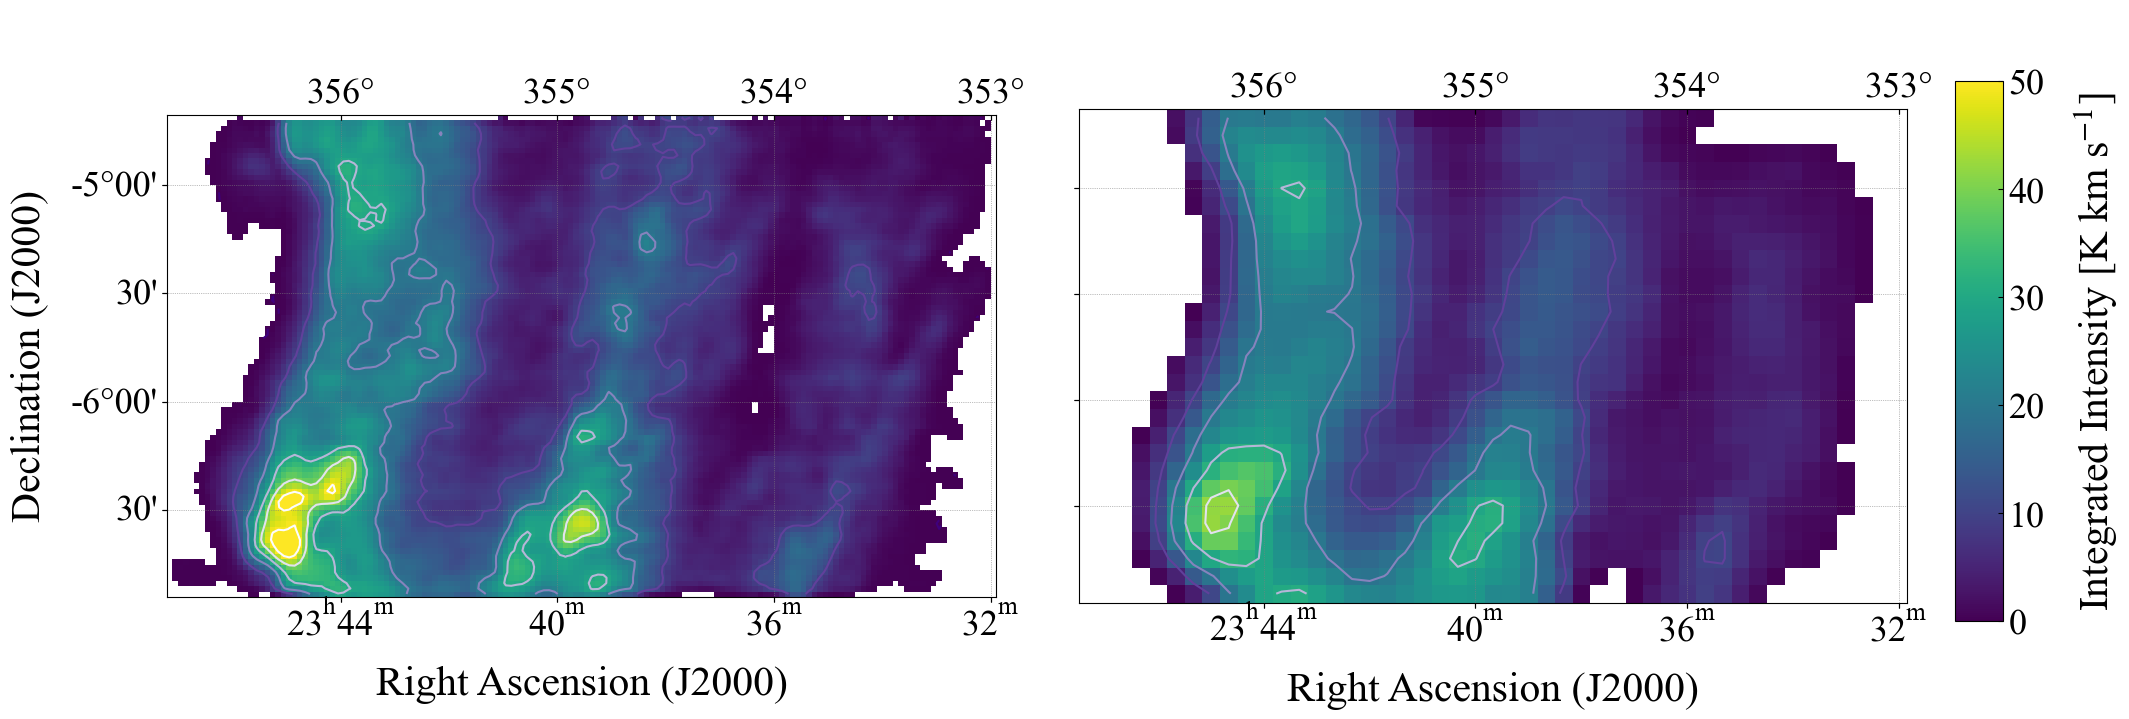

In [70]:

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'  # Use STIX math fonts to match Times-style text.

# Use GridSpec to define the subplot layout.
fig = plt.figure(figsize=(24, 9))  # Increase width to fit two subplots.
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.1)

# Create two subplots, both using the moment_0.wcs projection.
ax1 = fig.add_subplot(gs[0], projection=moment_0.wcs)
ax2 = fig.add_subplot(gs[1], projection=moment_0_H.wcs)

# Show the moment-map image on both subplots.
im1 = ax1.imshow(moment_0.hdu.data, cmap='viridis', vmin=0, vmax=50)
im2 = ax2.imshow(moment_0_H.hdu.data, cmap='viridis', vmin=0, vmax=50)

# Configure the axes of both subplots.
for ax in [ax1, ax2]:
    # Set axis labels.
    ax.set_xlabel("Right Ascension (J2000)", fontsize=30, fontname='Times New Roman', labelpad=1)
    ax.set_ylabel("Declination (J2000)", fontsize=30, fontname='Times New Roman', labelpad=1)
    ax.tick_params(axis='both', which='both', direction='out', labelsize=26)
    
    # Configure WCS axes.
    ax.coords[0].set_ticks_position('b')  # Place major RA ticks at the bottom.
    ax.coords[1].set_ticks_position('l')  # Place major Dec ticks on the left.
    
    # Set main axis format: RA in hours and Dec in degrees.
    ax.coords[0].set_format_unit(u.hourangle)  # Set RA units to hours.
    ax.coords[1].set_format_unit(u.deg)        # Set Dec units to degrees.
    
    # Create an upper secondary RA axis in degrees.
    overlay_ra_deg = ax.get_coords_overlay('fk5')
    overlay_ra_deg[0].set_axislabel(' ', fontsize=30, fontname='Times New Roman', minpad=1)
    overlay_ra_deg[0].tick_params(labelsize=26, direction='in')
    overlay_ra_deg[0].set_ticks_position('t')  # Show at the top.
    overlay_ra_deg[0].set_format_unit(u.deg)   # Display in degrees.
    
    # Hide unused axes.
    overlay_ra_deg[1].set_axislabel('')
    overlay_ra_deg[1].set_ticklabel_visible(False)
    overlay_ra_deg[1].set_ticks_visible(False)
    overlay_ra_deg.grid(color='grey', ls='dotted', lw=0.5)
    

# Hide y-axis labels and ticks for the second subplot to avoid duplication.
ax2.set_ylabel('')  # Hide the y-axis label.
ax2.coords[1].set_ticklabel_visible(False)  # Hide y-axis tick labels.
ax2.coords[1].set_ticks_visible(True)  # Keep tick marks.
ax2.tick_params(axis='y', which='both', labelleft=False)  # Hide left-side tick labels.

contour1 = ax1.contour(moment_0.hdu.data, cmap='Purples_r', alpha=1,linewidths=1.5, levels=[0,10,20,30,40,50])
contour2 = ax2.contour(moment_0_H.hdu.data, cmap='Purples_r', alpha=1,linewidths=1.5, levels=[0,10,20,30,40,50])
# Add a shared colorbar on the far right.
# Reserve space for the colorbar by adjusting subplot positions.
fig.subplots_adjust(right=0.85)  # Leave room for the right-side colorbar.

# Create the colorbar axis.
cbar_ax = fig.add_axes([0.87, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(im2, cax=cbar_ax)
cbar.set_label('Integrated Intensity [K km s$^{-1}$]', size=30, labelpad=20)
cbar.ax.tick_params(labelsize=26, direction='in')

# Save the figure.
plt.savefig("./CRAFTS_HI4PI_moment0.pdf", dpi=300, bbox_inches="tight")

### Compare centroid velocity

Plot the two intensity-weighted velocity maps using a common velocity range and overlay integrated-intensity contours for spatial reference.

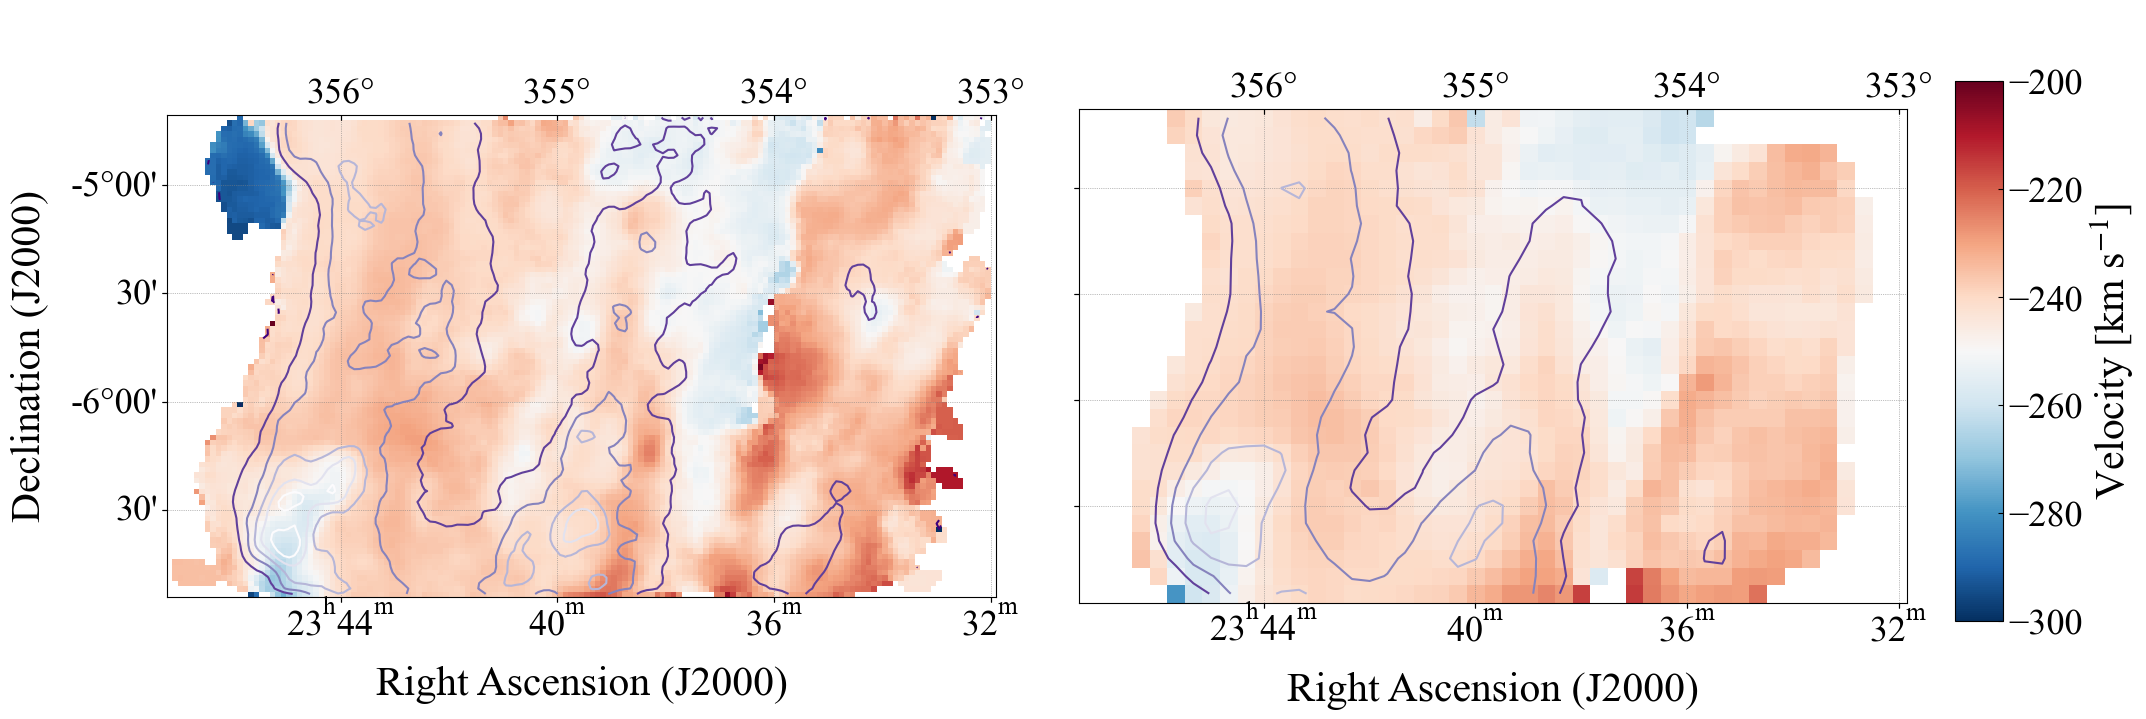

In [15]:

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'  # Use STIX math fonts to match Times-style text.

# Use GridSpec to define the subplot layout.
fig = plt.figure(figsize=(24, 9))  # Increase width to fit two subplots.
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.1)

# Create two subplots, both using the moment_0.wcs projection.
ax1 = fig.add_subplot(gs[0], projection=moment_0.wcs)
ax2 = fig.add_subplot(gs[1], projection=moment_0_H.wcs)

# Show the moment-map image on both subplots.
im1 = ax1.imshow(moment_1.hdu.data, cmap='RdBu_r', vmin=-300, vmax=-200)
im2 = ax2.imshow(moment_1_H.hdu.data, cmap='RdBu_r', vmin=-300, vmax=-200)

# Configure the axes of both subplots.
for ax in [ax1, ax2]:
    # Set axis labels.
    ax.set_xlabel("Right Ascension (J2000)", fontsize=30, fontname='Times New Roman', labelpad=1)
    ax.set_ylabel("Declination (J2000)", fontsize=30, fontname='Times New Roman', labelpad=1)
    ax.tick_params(axis='both', which='both', direction='out', labelsize=26)
    
    # Configure WCS axes.
    ax.coords[0].set_ticks_position('b')  # Place major RA ticks at the bottom.
    ax.coords[1].set_ticks_position('l')  # Place major Dec ticks on the left.
    
    # Set main axis format: RA in hours and Dec in degrees.
    ax.coords[0].set_format_unit(u.hourangle)  # Set RA units to hours.
    ax.coords[1].set_format_unit(u.deg)        # Set Dec units to degrees.
    
    # Create an upper secondary RA axis in degrees.
    overlay_ra_deg = ax.get_coords_overlay('fk5')
    overlay_ra_deg[0].set_axislabel(' ', fontsize=30, fontname='Times New Roman', minpad=1)
    overlay_ra_deg[0].tick_params(labelsize=26, direction='in')
    overlay_ra_deg[0].set_ticks_position('t')  # Show at the top.
    overlay_ra_deg[0].set_format_unit(u.deg)   # Display in degrees.
    
    # Hide unused axes.
    overlay_ra_deg[1].set_axislabel('')
    overlay_ra_deg[1].set_ticklabel_visible(False)
    overlay_ra_deg[1].set_ticks_visible(False)
    overlay_ra_deg.grid(color='grey', ls='dotted', lw=0.5)
    

# Hide y-axis labels and ticks for the second subplot to avoid duplication.
ax2.set_ylabel('')  # Hide the y-axis label.
ax2.coords[1].set_ticklabel_visible(False)  # Hide y-axis tick labels.
ax2.coords[1].set_ticks_visible(True)  # Keep tick marks.
ax2.tick_params(axis='y', which='both', labelleft=False)  # Hide left-side tick labels.

contour1 = ax1.contour(moment_0.hdu.data, cmap='Purples_r', alpha=1,linewidths=1.5, levels=[0,10,20,30,40,50])
contour2 = ax2.contour(moment_0_H.hdu.data, cmap='Purples_r', alpha=1,linewidths=1.5, levels=[0,10,20,30,40,50])
# Add a shared colorbar on the far right.
# Reserve space for the colorbar by adjusting subplot positions.
fig.subplots_adjust(right=0.85)  # Leave room for the right-side colorbar.

# Create the colorbar axis.
cbar_ax = fig.add_axes([0.87, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(im2, cax=cbar_ax)
cbar.set_label('Velocity [km s$^{-1}$]', size=30)
cbar.ax.tick_params(labelsize=26, direction='in')

# Save the figure.
plt.savefig("./CRAFTS_HI4PI_moment1.pdf", dpi=300, bbox_inches="tight")

### Compare line width

Plot the CRAFTS and HI4PI FWHM maps with consistent WCS formatting, limits, and contours.

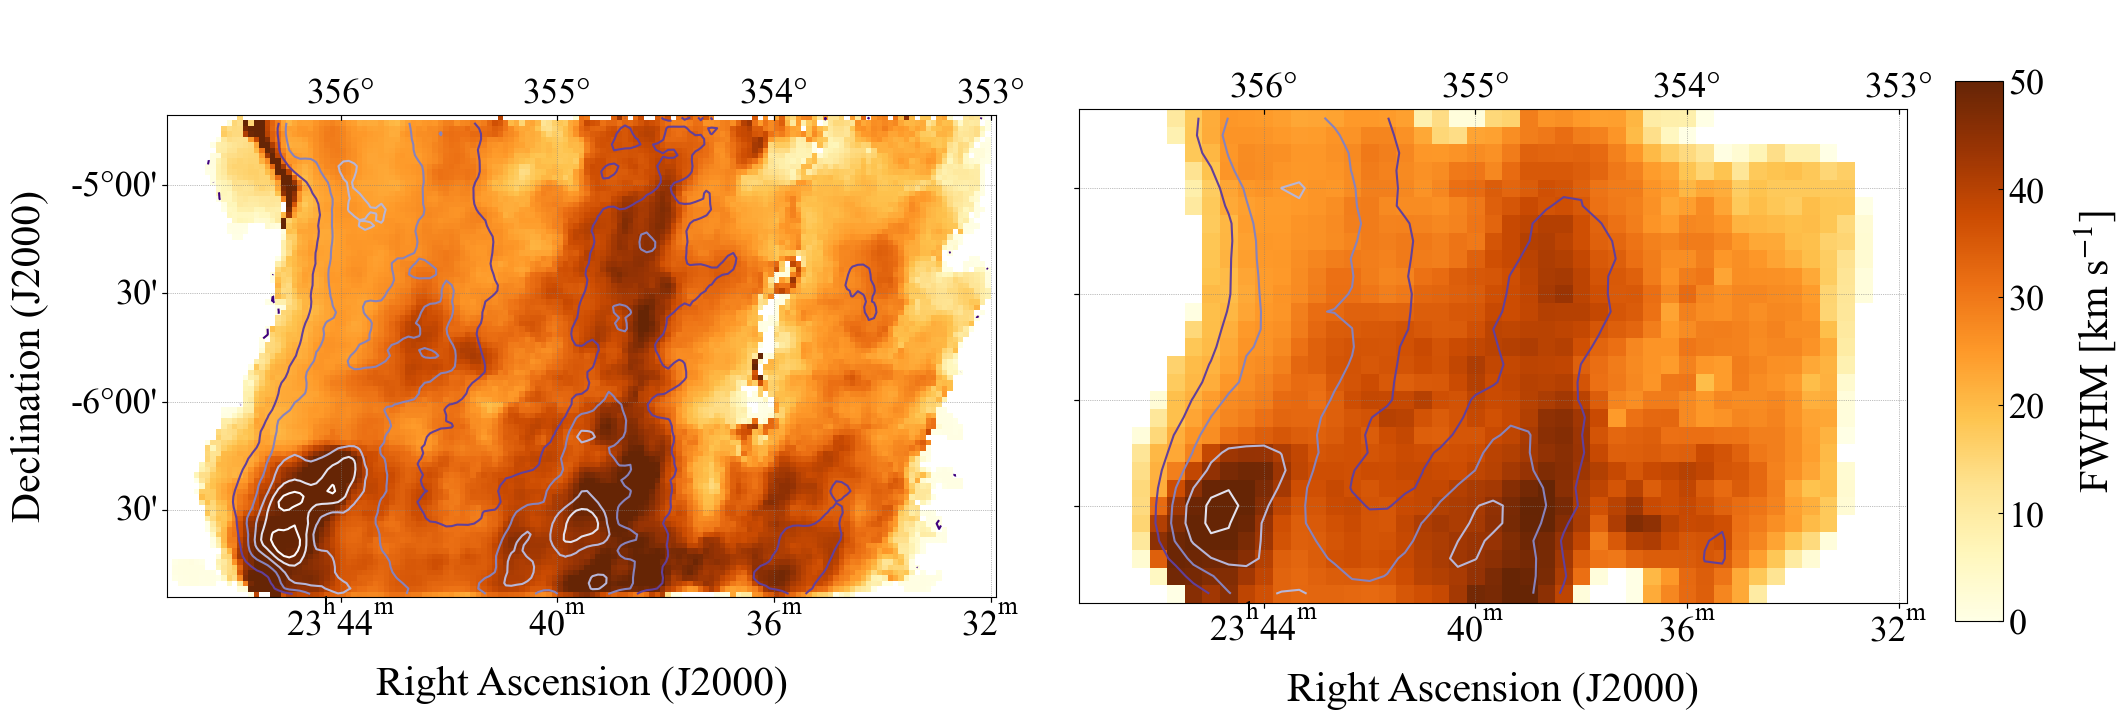

In [16]:

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'  # Use STIX math fonts to match Times-style text.

# Use GridSpec to define the subplot layout.
fig = plt.figure(figsize=(24, 9))  # Increase width to fit two subplots.
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.1)

# Create two subplots, both using the moment_0.wcs projection.
ax1 = fig.add_subplot(gs[0], projection=moment_0.wcs)
ax2 = fig.add_subplot(gs[1], projection=moment_0_H.wcs)

# Show the moment-map image on both subplots.
im1 = ax1.imshow(moment_2.hdu.data, cmap='YlOrBr', vmin=0, vmax=50)
im2 = ax2.imshow(moment_2_H.hdu.data, cmap='YlOrBr', vmin=0, vmax=50)

# Configure the axes of both subplots.
for ax in [ax1, ax2]:
    # Set axis labels.
    ax.set_xlabel("Right Ascension (J2000)", fontsize=30, fontname='Times New Roman', labelpad=1)
    ax.set_ylabel("Declination (J2000)", fontsize=30, fontname='Times New Roman', labelpad=1)
    ax.tick_params(axis='both', which='both', direction='out', labelsize=26)
    
    # Configure WCS axes.
    ax.coords[0].set_ticks_position('b')  # Place major RA ticks at the bottom.
    ax.coords[1].set_ticks_position('l')  # Place major Dec ticks on the left.
    
    # Set main axis format: RA in hours and Dec in degrees.
    ax.coords[0].set_format_unit(u.hourangle)  # Set RA units to hours.
    ax.coords[1].set_format_unit(u.deg)        # Set Dec units to degrees.
    
    # Create an upper secondary RA axis in degrees.
    overlay_ra_deg = ax.get_coords_overlay('fk5')
    overlay_ra_deg[0].set_axislabel(' ', fontsize=30, fontname='Times New Roman', minpad=1)
    overlay_ra_deg[0].tick_params(labelsize=26, direction='in')
    overlay_ra_deg[0].set_ticks_position('t')  # Show at the top.
    overlay_ra_deg[0].set_format_unit(u.deg)   # Display in degrees.
    
    # Hide unused axes.
    overlay_ra_deg[1].set_axislabel('')
    overlay_ra_deg[1].set_ticklabel_visible(False)
    overlay_ra_deg[1].set_ticks_visible(False)
    overlay_ra_deg.grid(color='grey', ls='dotted', lw=0.5)
    

# Hide y-axis labels and ticks for the second subplot to avoid duplication.
ax2.set_ylabel('')  # Hide the y-axis label.
ax2.coords[1].set_ticklabel_visible(False)  # Hide y-axis tick labels.
ax2.coords[1].set_ticks_visible(True)  # Keep tick marks.
ax2.tick_params(axis='y', which='both', labelleft=False)  # Hide left-side tick labels.

contour1 = ax1.contour(moment_0.hdu.data, cmap='Purples_r', alpha=1,linewidths=1.5, levels=[0,10,20,30,40,50])
contour2 = ax2.contour(moment_0_H.hdu.data, cmap='Purples_r', alpha=1,linewidths=1.5, levels=[0,10,20,30,40,50])
# Add a shared colorbar on the far right.
# Reserve space for the colorbar by adjusting subplot positions.
fig.subplots_adjust(right=0.85)  # Leave room for the right-side colorbar.

# Create the colorbar axis.
cbar_ax = fig.add_axes([0.87, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(im2, cax=cbar_ax)
cbar.set_label('FWHM [km s$^{-1}$]', size=30, labelpad=20)
cbar.ax.tick_params(labelsize=26, direction='in')

# Save the figure.
plt.savefig("./CRAFTS_HI4PI_fwhm.pdf", dpi=300, bbox_inches="tight")

## 5. Configure position-velocity extraction

Import the PV extraction tools and reopen the prepared CRAFTS cube using the centralized path configuration.

In [17]:

from spectral_cube import SpectralCube
import pylab as pl
from pvextractor import extract_pv_slice, Path
cube = SpectralCube.read("./CRAFTS_-4.7_-350_-150_baseline.fits")
cube

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: km / s  range:     -349.903 km / s:    -150.028 km / s

### Select the PV sky field

Apply the same celestial cutout used in the moment-map analysis.

In [18]:

x_range = [356.8, 352.9] * u.deg
y_range = [-6.89, -4.69] * u.deg
# SpectralCube handles reversed right-ascension bounds through WCS.
sub_cube = cube.subcube(
    xlo=x_range[0], xhi=x_range[1],
    ylo=y_range[0], yhi=y_range[1],)

print(sub_cube)

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: km / s  range:     -349.903 km / s:    -150.028 km / s


### Select the PV velocity interval

Limit the cube to the high-velocity interval sampled by all PV tracks.

In [19]:

sub_cube_slab = cube.spectral_slab(-300*u.km / u.s,  -200*u.km / u.s)
print(sub_cube_slab)

SpectralCube with shape=(498, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    498  type_s: VOPT      unit_s: km / s  range:     -299.985 km / s:    -199.947 km / s


### Inspect one velocity channel

Display a representative plane to verify orientation and emission coverage before defining tracks.

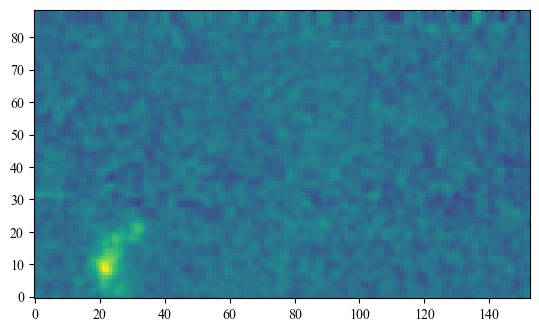

In [20]:

pl.imshow(sub_cube_slab[400].value, origin='lower')

### Define the X1, X2, and X3 tracks

Create three pixel-coordinate PV paths and assign the extraction width used for each track.

In [21]:

# #X1  100
path1 = Path([(35,0), (39,89)], width=90*u.arcmin)
# #X2  85
path2 = Path([(84,0), (92,89)], width=70*u.arcmin)
##X3   30
path3 = Path([(124,0), (135,89)], width=50*u.arcmin)

### Verify track placement

Overlay the three tracks on the sky image before extracting PV slices.

/Users/macx/Documents/Codex/2026-08-19/https-github-com-astroyxyxyx-hvc-https/work/HVC/.venv/lib/python3.9/site-packages/pvextractor/geometry/path.py:262: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patches.append(MPLPolygon(list(zip(poly.x, poly.y)), **kwargs))
/Users/macx/Documents/Codex/2026-08-19/https-github-com-astroyxyxyx-hvc-https/work/HVC/.venv/lib/python3.9/site-packages/pvextractor/geometry/path.py:262: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patches.append(MPLPolygon(list(zip(poly.x, poly.y)), **kwargs))
/Users/macx/Documents/Codex/2026-08-19/https-github-com-astroyxyxyx-hvc-https/work/HVC/.venv/lib/python3.9/site-packages/pvextractor/geometry/path.py:262: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patches.append(MPLPolygon(list(zip(poly.x, poly.y)), **kwargs))


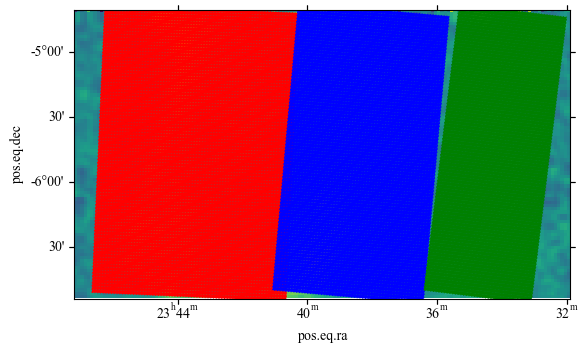

In [22]:

ax = pl.subplot(111, projection=sub_cube_slab.wcs.celestial)
ax.imshow(sub_cube[500].value)
path1.show_on_axis(ax, spacing=1, color='r' ,linestyle=':',
                      linewidth=0.75)
path2.show_on_axis(ax, spacing=1, color='b' ,linestyle=':',
                      linewidth=0.75)
path3.show_on_axis(ax, spacing=1, color='g' ,linestyle=':',
                      linewidth=0.75)

### Extract PV slices

Sample the CRAFTS slab along each track at one-pixel spacing.

In [23]:

pvdiagram1 = extract_pv_slice(cube=sub_cube_slab, path=path1, spacing=1)
pvdiagram2 = extract_pv_slice(cube=sub_cube_slab, path=path2, spacing=1)
pvdiagram3 = extract_pv_slice(cube=sub_cube_slab, path=path3, spacing=1)

### Build the overview image

Collapse the spectral slab with a channel-wise maximum for the PV overview panel.

In [24]:

mx = sub_cube_slab.max(axis=0).value

### Plot the PV overview and slices

Assemble a four-panel figure containing the track overview and three WCS-aware PV diagrams, with consistent brightness-temperature scales and contour levels.

/var/folders/8n/cx5n87ys1lj215xv6txs4_4c0000gn/T/ipykernel_54263/10996104.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


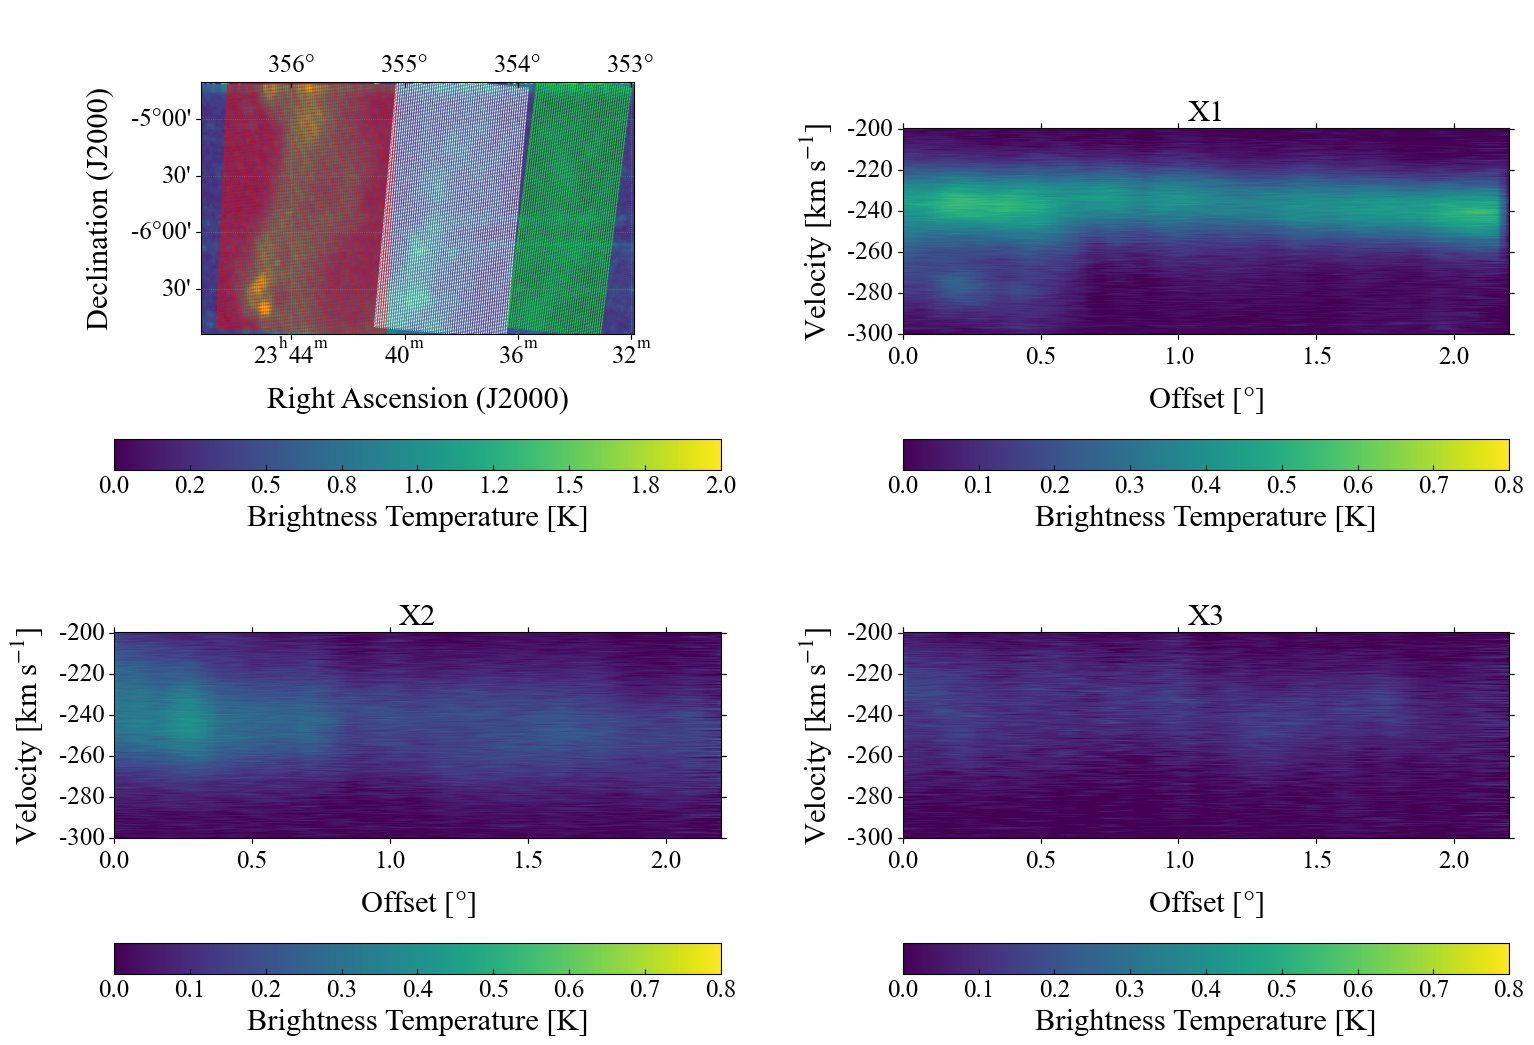

In [25]:

import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import astropy.wcs as wcs
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

# Required upstream products from the preceding PV extraction cells:
# sub_cube: spatially cropped CRAFTS cube.
# mx: maximum brightness-temperature map for the overview panel.
# path1/path2/path3: PV extraction tracks.
# pvdiagram1/pvdiagram2/pvdiagram3: Data for the three PV diagrams, each with a header attribute.

# ====================== 1. Initialize the canvas and layout. ======================
fig = plt.figure(figsize=(18, 12))  # Four-panel canvas sized for WCS labels and colorbars.
# Define a 2x2 grid layout and adjust spacing to avoid overlaps.
gs = fig.add_gridspec(2, 2, hspace=0.2, wspace=0.3)

# ====================== 2. Panel 1: original cube overview in the upper left. ======================
ax_original = fig.add_subplot(gs[0, 0], projection=sub_cube_slab.wcs.celestial)
# Plot the original slice data with origin='lower' to keep coordinate orientation correct.
im_original = ax_original.imshow(mx, vmin=0, vmax=2 ,origin='lower')
# ax_original.set_aspect(0.7)
# Annotate the path.
# path.show_on_axis(ax_original, spacing=1, edgecolor='r', linestyle=':', linewidth=0.75)
path1.show_on_axis(ax_original, spacing=0.5,
                  edgecolor='r', linestyle=':',
                  linewidth=0.6)
path2.show_on_axis(ax_original, spacing=0.5,
                  edgecolor='w', linestyle=':',
                  linewidth=0.6)
path3.show_on_axis(ax_original, spacing=0.5,
                  edgecolor='lime', linestyle=':',
                  linewidth=0.6)



ax_original.set_xlabel("Right Ascension (J2000)", fontsize=22, fontname='Times New Roman', labelpad=1)
ax_original.set_ylabel("Declination (J2000)", fontsize=22, fontname='Times New Roman', labelpad=1)
ax_original.tick_params(axis='both', which='both', direction='out', labelsize=18)

# Configure WCS axes.
ax_original.coords[0].set_ticks_position('b')  # Place major RA ticks at the bottom.
ax_original.coords[1].set_ticks_position('l')  # Place major Dec ticks on the left.

# Set main axis format: RA in hours and Dec in degrees.
ax_original.coords[0].set_format_unit(u.hourangle)  # Set RA units to hours.
ax_original.coords[1].set_format_unit(u.deg)       # Set Dec units to degrees.

# Create an upper secondary RA axis in degrees.
overlay1_ra_deg = ax_original.get_coords_overlay('fk5')
overlay1_ra_deg[0].set_axislabel(' ', fontsize=22, fontname='Times New Roman', minpad=1)
overlay1_ra_deg[0].tick_params(labelsize=18, direction='in')
overlay1_ra_deg[0].set_ticks_position('t')  # Show at the top.
overlay1_ra_deg[0].set_format_unit(u.deg)  # Display in degrees.

# Hide unused axes.
overlay1_ra_deg[1].set_axislabel('')
overlay1_ra_deg[1].set_ticklabel_visible(False)
overlay1_ra_deg[1].set_ticks_visible(False)
overlay1_ra_deg.grid(color='grey', ls='dotted', lw=0.5)

# Add a colorbar to the original image, using K as the shared unit.
cb_original = fig.colorbar(im_original, ax=ax_original, pad=.25,location = 'bottom')
cb_original.set_label("Brightness Temperature [K]", size=22)
cb_original.ax.tick_params(labelsize=18, direction='in')
cb_original.ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
# ====================== 3. Panel 2: PV diagram 1 in the upper right. ======================
# Read the WCS for PV diagram 1.
wcs_pv1 = wcs.WCS(pvdiagram1.header)
ax_pv1 = fig.add_subplot(gs[0, 1], projection=wcs_pv1)
im_pv1 = ax_pv1.imshow(pvdiagram1.data, origin='lower', vmin=0, vmax=0.8)
ax_pv1.set_aspect(0.06)

# Replace non-finite PV values only in the local plotting copy.
data_pv1 = pvdiagram1.data.copy()
if np.isnan(data_pv1).any():
    data_pv1 = np.nan_to_num(data_pv1, nan=0)

# Set axis units and ticks.
deg_min = 0.0  # Minimum angle.
deg_max = 2.2  # Maximum angle.

# Method 1.1: use the WCS all_world2pix method.
world_coords_min = [[deg_min, 0]]  # [offset, velocity],velocity can be any value.
world_coords_max = [[deg_max, 0]]
pixel_coords_min = wcs_pv1.all_world2pix(world_coords_min, 0)
pixel_coords_max = wcs_pv1.all_world2pix(world_coords_max, 0)

# Set pixel-coordinate limits.
ax_pv1.set_xlim(pixel_coords_min[0][0], pixel_coords_max[0][0])

coord_pv1_x = ax_pv1.coords[0]
coord_pv1_x.set_format_unit(u.deg)
coord_pv1_x.tick_params(axis='both', which='both', direction='out', labelsize=18)


coord_pv1_y = ax_pv1.coords[1]
coord_pv1_y.set_format_unit(u.km / u.s)
coord_pv1_y.tick_params(axis='both', which='both', direction='out', labelsize=18)

# Add the colorbar.
cb_pv1 = fig.colorbar(im_pv1, ax=ax_pv1, pad=.25,location = 'bottom')
cb_pv1.set_label("Brightness Temperature [K]", size=22)
cb_pv1.ax.tick_params(labelsize=18, direction='in')

# Overlay contours from PV diagram 1.
contour_pv1 = ax_pv1.contour(data_pv1, levels=[1.0, 1.4, 1.8], colors='black', linewidths=1)
ax_pv1.clabel(contour_pv1, inline=True, fontsize=18)

# Set labels and title.
ax_pv1.set_ylabel("Velocity [km s$^{-1}$]", fontsize=22)
ax_pv1.set_xlabel("Offset [$°$]", fontsize=22)
ax_pv1.set_title("X1", fontsize=22)
ax_pv1.invert_yaxis()
# ====================== 4. Panel 3: PV diagram 2 in the lower left. ======================
# Construct the WCS for PV diagram 2.
wcs_pv2 = wcs.WCS(pvdiagram2.header)
ax_pv2 = fig.add_subplot(gs[1, 0], projection=wcs_pv2)
im_pv2 = ax_pv2.imshow(pvdiagram2.data, origin='lower', vmin=0, vmax=0.8)
ax_pv2.set_aspect(0.06)

# Replace non-finite values in the PV diagram 2 plotting copy.
data_pv2 = pvdiagram2.data.copy()
if np.isnan(data_pv2).any():
    data_pv2 = np.nan_to_num(data_pv2, nan=0)

ax_pv2.set_xlim(pixel_coords_min[0][0], pixel_coords_max[0][0])
# Set axis units and ticks.
coord_pv2_x = ax_pv2.coords[0]
coord_pv2_x.set_format_unit(u.deg)
coord_pv2_x.tick_params(axis='both', which='both', direction='out', labelsize=18)

coord_pv2_y = ax_pv2.coords[1]
coord_pv2_y.set_format_unit(u.km / u.s)
coord_pv2_y.tick_params(axis='both', which='both', direction='out', labelsize=18)

# Add the colorbar.
cb_pv2 = fig.colorbar(im_pv2, ax=ax_pv2, pad=.25,location = 'bottom')
cb_pv2.set_label("Brightness Temperature [K]", size=22)
cb_pv2.ax.tick_params(labelsize=18, direction='in')

# Overlay contours from PV diagram 2.
contour_pv2 = ax_pv2.contour(data_pv2, levels=[1.0, 1.4, 1.8], colors='black', linewidths=1)
ax_pv2.clabel(contour_pv2, inline=True, fontsize=18)

# Set labels and title.
ax_pv2.set_ylabel("Velocity [km s$^{-1}$]", fontsize=22)
ax_pv2.set_xlabel("Offset [$°$]", fontsize=22)
ax_pv2.set_title("X2", fontsize=22)
ax_pv2.invert_yaxis()
# ====================== 5. Panel 4: PV diagram 3 in the lower right. ======================
# Construct the WCS for PV diagram 3.
wcs_pv3 = wcs.WCS(pvdiagram3.header)
ax_pv3 = fig.add_subplot(gs[1, 1], projection=wcs_pv3)
im_pv3 = ax_pv3.imshow(pvdiagram3.data, origin='lower', vmin=0, vmax=0.8)
ax_pv3.set_aspect(0.06)

# Replace non-finite values in the PV diagram 3 plotting copy.
data_pv3 = pvdiagram3.data.copy()
if np.isnan(data_pv3).any():
    data_pv3 = np.nan_to_num(data_pv3, nan=0)

ax_pv3.set_xlim(pixel_coords_min[0][0], pixel_coords_max[0][0])
# Set axis units and ticks.
coord_pv3_x = ax_pv3.coords[0]
coord_pv3_x.set_format_unit(u.deg)
coord_pv3_x.tick_params(axis='both', which='both', direction='out', labelsize=18)

coord_pv3_y = ax_pv3.coords[1]
coord_pv3_y.set_format_unit(u.km / u.s)
coord_pv3_y.tick_params(axis='both', which='both', direction='out', labelsize=18)

# Add the colorbar.
cb_pv3 = fig.colorbar(im_pv3, ax=ax_pv3, pad=.25,location = 'bottom')
cb_pv3.set_label("Brightness Temperature [K]", size=22)
cb_pv3.ax.tick_params(labelsize=18, direction='in')

# Overlay contours from PV diagram 3.
contour_pv3 = ax_pv3.contour(data_pv3, levels=[1.0, 1.4, 1.8], colors='black', linewidths=1)
ax_pv3.clabel(contour_pv3, inline=True, fontsize=18)

# Set labels and title.
ax_pv3.set_ylabel("Velocity [km s$^{-1}$]", fontsize=22)
ax_pv3.set_xlabel("Offset [$°$]", fontsize=22)
ax_pv3.set_title("X3", fontsize=22)
ax_pv3.invert_yaxis()

# ====================== 6. Save and display. ======================
# Optimize layout to keep labels and colorbars inside the canvas.
plt.tight_layout()
plt.savefig("./CRAFTS_pv_overview.pdf", dpi=300, bbox_inches="tight")
# plt.show()


## 6. Measure velocity trends along the tracks

Bin track pixels by declination, detect separated spectral peaks near -240 and -280 km/s, estimate beam-corrected uncertainties, and write one result row per path and declination bin.

In [28]:

import numpy as np
import pandas as pd
import astropy.units as u
from spectral_cube import SpectralCube
from astropy.wcs.utils import proj_plane_pixel_scales
from scipy.signal import find_peaks


"""
Estimate uncertainty using the beam size.
Workflow:
1. Select pixels along the X1, X2, and X3 paths.
2. Bin by Dec every 0.5 deg.
3. For each Dec bin, first use the average spectrum to test whether two peaks are present.
4. If two peaks are detected, measure peak velocities near -240 km/s and -280 km/s separately.
"""


# =========================
# 1. Read the cube.
# =========================

cube = SpectralCube.read(
    "./CRAFTS_-4.7_-350_-150_baseline_Jy_mask----mask-K.fits"
)

cube = cube.with_spectral_unit(u.km / u.s)

vel = cube.spectral_axis.to_value(u.km / u.s)

# Use filled_data instead if strict masking is desired.
# data = cube.with_fill_value(np.nan).filled_data[:].value
data = cube.unmasked_data[:].value   # shape: (n_v, n_y, n_x)

print(cube)
print("Velocity range:", np.nanmin(vel), np.nanmax(vel), "km/s")


# =========================
# 2. Define paths.
# =========================

paths = [
    ("X1", (35, 0),  (39, 89),   90 * u.arcmin),
    ("X2", (84, 0),  (92, 89),   70 * u.arcmin),
    ("X3", (124, 0), (135, 89),  50 * u.arcmin),
]


# =========================
# 3. Basic spatial information.
# =========================

ny, nx = cube.shape[1], cube.shape[2]

yy, xx = np.mgrid[0:ny, 0:nx]

world = cube.wcs.celestial.pixel_to_world(xx, yy)
ra_map = world.ra.deg
dec_map = world.dec.deg

pixscale_deg = np.mean(
    np.abs(proj_plane_pixel_scales(cube.wcs.celestial))
) * u.deg

pixscale_arcmin = pixscale_deg.to(u.arcmin)

pix_area = pixscale_arcmin**2

print("Pixel scale:", pixscale_arcmin)
print("Pixel area:", pix_area)


# =========================
# 4. Beam information.
# =========================
# Assume a circular Gaussian beam with FWHM = 4 arcmin.
# Gaussian beam area = 1.1331 * FWHM^2
# =========================

beam_fwhm = 4.0 * u.arcmin
beam_area = 1.1331 * beam_fwhm**2

print("Beam FWHM:", beam_fwhm)
print("Beam area:", beam_area)


# =========================
# 5. Helper function: compute distance from pixels to the path centerline.
# =========================

def distance_to_line_pixels(xx, yy, p1, p2):
    """Compute the shortest pixel distance to a finite line segment.

        Parameters
        ----------
        xx, yy : numpy.ndarray
            Two-dimensional x- and y-coordinate grids in pixel units.
        p1, p2 : tuple of float
            ``(x, y)`` endpoints of the path centerline.

        Returns
        -------
        numpy.ndarray
            Per-pixel Euclidean distance to the nearest point on the segment.

        Raises
        ------
        ValueError
            If the two endpoints are identical."""

    x1, y1 = p1
    x2, y2 = p2

    px = xx - x1
    py = yy - y1

    vx = x2 - x1
    vy = y2 - y1

    line_len2 = vx**2 + vy**2

    if line_len2 == 0:
        raise ValueError("p1 and p2 are identical; cannot define a path.")

    t = (px * vx + py * vy) / line_len2
    t = np.clip(t, 0, 1)

    proj_x = x1 + t * vx
    proj_y = y1 + t * vy

    dist = np.sqrt((xx - proj_x)**2 + (yy - proj_y)**2)

    return dist


# =========================
# 6. Helper function: find the peak velocity within a velocity window.
# =========================

def get_peak_velocity(mean_spec, vel, vmin, vmax):
    """Return the brightest spectral channel inside a velocity interval.

        Parameters
        ----------
        mean_spec : array-like
            One-dimensional mean brightness-temperature spectrum.
        vel : array-like
            Velocity coordinate in km/s, aligned with ``mean_spec``.
        vmin, vmax : float
            Inclusive velocity bounds in km/s.

        Returns
        -------
        v_peak : float
            Velocity of the maximum finite channel, or NaN if none is available.
        T_peak : float
            Brightness temperature at ``v_peak``, or NaN if none is available."""

    mask = (vel >= vmin) & (vel <= vmax)

    if np.sum(mask) == 0:
        return np.nan, np.nan

    v_sub = vel[mask]
    s_sub = mean_spec[mask]

    good = np.isfinite(s_sub)

    if np.sum(good) == 0:
        return np.nan, np.nan

    v_sub = v_sub[good]
    s_sub = s_sub[good]

    idx = np.nanargmax(s_sub)

    return v_sub[idx], s_sub[idx]


def get_peak_velocity_stats(
    spectra,
    vel,
    vmin,
    vmax,
    min_peak_K=None,
    pix_area=None,
    beam_area=None
):
    """Summarize per-pixel peak velocities within one declination bin.

        Each spatial pixel contributes the brightest finite channel inside the requested
        velocity interval. When pixel and beam areas are supplied, the uncertainty on
        the mean uses an effective independent-beam count rather than the raw pixel count.

        Parameters
        ----------
        spectra : numpy.ndarray
            Spectra in ``(velocity channel, spatial pixel)`` order.
        vel : array-like
            Velocity coordinate in km/s.
        vmin, vmax : float
            Inclusive velocity bounds in km/s.
        min_peak_K : float, optional
            Minimum accepted peak brightness temperature in kelvin.
        pix_area : astropy.units.Quantity, optional
            Solid-angle area represented by one image pixel.
        beam_area : astropy.units.Quantity, optional
            Gaussian beam area in units compatible with ``pix_area``.

        Returns
        -------
        v_mean : float
            Mean accepted peak velocity in km/s.
        v_err : float
            Standard error of the mean using the effective beam count.
        v_std : float
            Sample standard deviation of accepted peak velocities.
        N_eff : int
            Number of accepted pixel spectra.
        N_beam : float
            Estimated number of independent beams.
        T_mean : float
            Mean accepted peak brightness temperature in kelvin."""

    mask_v = (vel >= vmin) & (vel <= vmax)

    if np.sum(mask_v) == 0:
        return np.nan, np.nan, np.nan, 0, np.nan, np.nan

    v_sub = vel[mask_v]
    s_sub = spectra[mask_v, :]   # shape = (nv_window, npix)

    v_peaks = []
    T_peaks = []

    for k in range(s_sub.shape[1]):

        spec_k = s_sub[:, k]

        good = np.isfinite(spec_k)

        if np.sum(good) == 0:
            continue

        v_k = v_sub[good]
        s_k = spec_k[good]

        if len(s_k) == 0:
            continue

        idx = np.nanargmax(s_k)

        v_peak = v_k[idx]
        T_peak = s_k[idx]

        if min_peak_K is not None and T_peak < min_peak_K:
            continue

        v_peaks.append(v_peak)
        T_peaks.append(T_peak)

    v_peaks = np.array(v_peaks, dtype=float)
    T_peaks = np.array(T_peaks, dtype=float)

    N_eff = np.sum(np.isfinite(v_peaks))

    if N_eff == 0:
        return np.nan, np.nan, np.nan, 0, np.nan, np.nan

    v_mean = np.nanmean(v_peaks)
    T_mean = np.nanmean(T_peaks)

    if N_eff == 1:
        v_std = np.nan
        v_err = np.nan
        N_beam = 1.0
    else:
        v_std = np.nanstd(v_peaks, ddof=1)

        if pix_area is not None and beam_area is not None:
            N_beam = (N_eff * pix_area / beam_area).decompose().value

            # Avoid artificially inflating the uncertainty when the region area is smaller than one beam.
            N_beam = max(N_beam, 1.0)

            v_err = v_std / np.sqrt(N_beam)
        else:
            N_beam = float(N_eff)
            v_err = v_std / np.sqrt(N_eff)

    return v_mean, v_err, v_std, N_eff, N_beam, T_mean


# =========================
# 7. Helper function: determine whether two peaks are present.
# =========================

def detect_two_peaks_in_mean_spectrum(
    mean_spec,
    vel,
    search_window=(-310, -220),
    peak_min_height=None,
    peak_min_prominence=0.05,
    peak_min_distance_kms=20.0,
    v240_window=(-265, -220),
    v280_window=(-310, -270),
):
    """Test whether a mean spectrum contains both target velocity components.

        Peaks are detected within ``search_window`` using SciPy prominence and separation
        criteria. A successful two-component detection requires at least one peak in each
        of the non-overlapping -240 and -280 km/s windows.

        Parameters
        ----------
        mean_spec : array-like
            Mean brightness-temperature spectrum.
        vel : array-like
            Velocity coordinate in km/s.
        search_window : tuple of float
            Inclusive velocity interval searched for peaks.
        peak_min_height : float, optional
            Minimum peak height passed to ``scipy.signal.find_peaks``.
        peak_min_prominence : float
            Minimum peak prominence in the spectrum's intensity units.
        peak_min_distance_kms : float
            Minimum velocity separation converted to a channel count.
        v240_window, v280_window : tuple of float
            Non-overlapping windows defining the two target components.

        Returns
        -------
        has_two_peaks : bool
            ``True`` only when both target windows contain a detected peak.
        info : dict
            Detection status, peak count, peak velocities and temperatures, and
            per-window presence flags."""

    mean_spec = np.asarray(mean_spec, dtype=float)
    vel = np.asarray(vel, dtype=float)

    empty_info = {
        "reason": "no_valid_detection",
        "n_peaks": 0,
        "v_peaks": np.array([], dtype=float),
        "T_peaks": np.array([], dtype=float),
        "has_240_peak": False,
        "has_280_peak": False,
    }

    mask = (
        np.isfinite(mean_spec)
        & np.isfinite(vel)
        & (vel >= search_window[0])
        & (vel <= search_window[1])
    )

    if np.sum(mask) < 5:
        empty_info["reason"] = "too_few_channels"
        return False, empty_info

    v_sub = vel[mask]
    s_sub = mean_spec[mask]

    # Estimate velocity-channel width.
    dv = np.nanmedian(np.abs(np.diff(v_sub)))

    if not np.isfinite(dv) or dv <= 0:
        dv = 1.0

    distance_chan = max(1, int(peak_min_distance_kms / dv))

    peaks, props = find_peaks(
        s_sub,
        height=peak_min_height,
        prominence=peak_min_prominence,
        distance=distance_chan,
    )

    if len(peaks) == 0:
        empty_info["reason"] = "no_peaks"
        return False, empty_info

    v_peaks = v_sub[peaks]
    T_peaks = s_sub[peaks]

    has_240 = np.any(
        (v_peaks >= v240_window[0])
        & (v_peaks <= v240_window[1])
    )

    has_280 = np.any(
        (v_peaks >= v280_window[0])
        & (v_peaks <= v280_window[1])
    )

    has_two_peaks = has_240 and has_280

    info = {
        "reason": "two_peaks_detected" if has_two_peaks else "missing_one_peak",
        "n_peaks": len(peaks),
        "v_peaks": v_peaks,
        "T_peaks": T_peaks,
        "has_240_peak": has_240,
        "has_280_peak": has_280,
    }

    return has_two_peaks, info


# =========================
# 8. Main loop.
# =========================

dec_step = 0.5  # deg

# Two non-overlapping windows.
v240_window = (-265, -220)
v280_window = (-310, -280)

# Full search range for two peaks.
two_peak_search_window = (-310, -220)

# find_peaks parameters
peak_min_height = None
peak_min_prominence = 0.05
peak_min_distance_kms = 20.0

results = []

for path_name, p1, p2, width in paths:

    width_pix = (width / pixscale_arcmin).decompose().value
    half_width_pix = width_pix / 2.0

    print("\n" + "=" * 60)
    print(f"Processing {path_name}")
    print("=" * 60)
    print("Width:", width)
    print("Width in pixels:", width_pix)

    dist_map = distance_to_line_pixels(xx, yy, p1, p2)

    path_mask = dist_map <= half_width_pix

    if not np.any(path_mask):
        print(f"Warning: {path_name} path_mask has no pixels. Skipping.")
        continue

    dec_min = np.nanmin(dec_map[path_mask])
    dec_max = np.nanmax(dec_map[path_mask])

    dec_edges = np.arange(dec_min, dec_max + dec_step, dec_step)

    for i in range(len(dec_edges) - 1):

        dec_low = dec_edges[i]
        dec_high = dec_edges[i + 1]
        dec_center = 0.5 * (dec_low + dec_high)

        dec_bin_mask = (
            path_mask
            & (dec_map >= dec_low)
            & (dec_map < dec_high)
        )

        n_pix = np.sum(dec_bin_mask)

        if n_pix == 0:
            continue

        spectra = data[:, dec_bin_mask]   # shape = (nv, npix)

        # -----------------------------------------------------
        # First use the average spectrum within this Dec bin to check for two peaks.
        # -----------------------------------------------------
        mean_spec = np.nanmean(spectra, axis=1)

        has_two_peaks, peak_info = detect_two_peaks_in_mean_spectrum(
            mean_spec,
            vel,
            search_window=two_peak_search_window,
            peak_min_height=peak_min_height,
            peak_min_prominence=peak_min_prominence,
            peak_min_distance_kms=peak_min_distance_kms,
            v240_window=v240_window,
            v280_window=v280_window,
        )

        print(
            f"{path_name}, DEC={dec_center:.2f}: "
            f"Npix={n_pix}, "
            f"two_peaks={has_two_peaks}, "
            f"detected_peaks={np.round(peak_info['v_peaks'], 2)}"
        )

        # -----------------------------------------------------
        # If two peaks are detected, find peaks near -240 and -280 km/s separately.
        # If two peaks are not detected, fill the result with NaN.
        # -----------------------------------------------------
       # -----------------------------------------------------
        # X1 and X2 require both the -240 and -280 km/s peaks.
        # X3 only searches for the -240 km/s peak and is not included in -280 km/s peak statistics.
        # -----------------------------------------------------
        if path_name == "X3":
        
            # X3 does not require two peaks; it searches directly in the -240 km/s window.
            (
                v_mean_240,
                v_err_240,
                v_std_240,
                n_eff_240,
                n_beam_240,
                T_mean_240,
            ) = get_peak_velocity_stats(
                spectra,
                vel,
                v240_window[0],
                v240_window[1],
                min_peak_K=None,
                pix_area=pix_area,
                beam_area=beam_area,
            )
        
            # All X3 results related to -280 km/s are filled with NaN.
            v_mean_280 = np.nan
            v_err_280 = np.nan
            v_std_280 = np.nan
            n_eff_280 = 0
            n_beam_280 = np.nan
            T_mean_280 = np.nan
        
        elif has_two_peaks:
        
            (
                v_mean_240,
                v_err_240,
                v_std_240,
                n_eff_240,
                n_beam_240,
                T_mean_240,
            ) = get_peak_velocity_stats(
                spectra,
                vel,
                v240_window[0],
                v240_window[1],
                min_peak_K=None,
                pix_area=pix_area,
                beam_area=beam_area,
            )
        
            (
                v_mean_280,
                v_err_280,
                v_std_280,
                n_eff_280,
                n_beam_280,
                T_mean_280,
            ) = get_peak_velocity_stats(
                spectra,
                vel,
                v280_window[0],
                v280_window[1],
                min_peak_K=None,
                pix_area=pix_area,
                beam_area=beam_area,
            )
        
        else:
        
            v_mean_240 = np.nan
            v_err_240 = np.nan
            v_std_240 = np.nan
            n_eff_240 = 0
            n_beam_240 = np.nan
            T_mean_240 = np.nan
        
            v_mean_280 = np.nan
            v_err_280 = np.nan
            v_std_280 = np.nan
            n_eff_280 = 0
            n_beam_280 = np.nan
            T_mean_280 = np.nan

        # -----------------------------------------------------
        # Save the result for this Dec bin.
        # -----------------------------------------------------
        results.append({
            "Path": path_name,
            "DEC_low_deg": dec_low,
            "DEC_high_deg": dec_high,
            "DEC_center_deg": dec_center,
            "N_pixels": n_pix,

            "Two_peaks_detected": has_two_peaks,
            "Peak_detection_reason": peak_info["reason"],
            "N_detected_peaks": peak_info["n_peaks"],
            "Detected_peak_velocities_kms": ",".join([
                f"{v:.2f}" for v in peak_info["v_peaks"]
            ]),
            "Has_240_peak": peak_info["has_240_peak"],
            "Has_280_peak": peak_info["has_280_peak"],

            "V_mean_240_kms": v_mean_240,
            "V_err_240_kms": v_err_240,
            "V_std_240_kms": v_std_240,
            "N_eff_240": n_eff_240,
            "N_beam_240": n_beam_240,
            "T_mean_peak_240_K": T_mean_240,

            "V_mean_280_kms": v_mean_280,
            "V_err_280_kms": v_err_280,
            "V_std_280_kms": v_std_280,
            "N_eff_280": n_eff_280,
            "N_beam_280": n_beam_280,
            "T_mean_peak_280_K": T_mean_280,
        })


# =========================
# 9. Save results.
# =========================

df = pd.DataFrame(results)

output_txt = "./PV_path_peak_velocity.txt"


df.to_csv(
    output_txt,
    sep="\t",
    index=False,
    float_format="%.4f"
)

print("\nSaved to:", output_txt)
print(df)


SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: km / s  range:     -348.002 km / s:    -148.527 km / s
Velocity range: -348.0020697326688 -148.52745408022054 km/s
Pixel scale: 1.5 arcmin
Pixel area: 2.25 arcmin2
Beam FWHM: 4.0 arcmin
Beam area: 18.1296 arcmin2

Processing X1
Width: 90.0 arcmin
Width in pixels: 60.0
X1, DEC=-6.64: Npix=1201, two_peaks=True, detected_peaks=[-232.5  -278.7  -306.22]
X1, DEC=-6.14: Npix=1201, two_peaks=True, detected_peaks=[-232.29 -278.9  -299.39]
X1, DEC=-5.64: Npix=1202, two_peaks=False, detected_peaks=[-233.7  -275.28]
X1, DEC=-5.14: Npix=1201, two_peaks=True, detected_peaks=[-236.31 -293.56]
X1, DEC=-4.64: Npix=540, two_peaks=True, detected_peaks=[-220.84 -241.13 -262.23 -301.8 ]

Processing X2
Width: 70.0 arcmin
Width in pixels: 46.666

/var/folders/8n/cx5n87ys1lj215xv6txs4_4c0000gn/T/ipykernel_54263/161214685.py:480: RuntimeWarning: Mean of empty slice
  mean_spec = np.nanmean(spectra, axis=1)


## 7. Plot peak velocity versus declination

Read the derived table, fit weighted linear trends for each path and velocity component, and display the measurements with uncertainties and fitted slopes.

Index(['Path', 'DEC_low_deg', 'DEC_high_deg', 'DEC_center_deg', 'N_pixels',
       'Two_peaks_detected', 'Peak_detection_reason', 'N_detected_peaks',
       'Detected_peak_velocities_kms', 'Has_240_peak', 'Has_280_peak',
       'V_mean_240_kms', 'V_err_240_kms', 'V_std_240_kms', 'N_eff_240',
       'N_beam_240', 'T_mean_peak_240_K', 'V_mean_280_kms', 'V_err_280_kms',
       'V_std_280_kms', 'N_eff_280', 'N_beam_280', 'T_mean_peak_280_K'],
      dtype='object')
  Path  DEC_low_deg  DEC_high_deg  DEC_center_deg  N_pixels  \
0   X1      -6.8875       -6.3875         -6.6375      1201   
1   X1      -6.3875       -5.8875         -6.1375      1201   
2   X1      -5.8875       -5.3875         -5.6375      1202   
3   X1      -5.3875       -4.8875         -5.1375      1201   
4   X1      -4.8875       -4.3875         -4.6375       540   

   Two_peaks_detected Peak_detection_reason  N_detected_peaks  \
0                True    two_peaks_detected                 3   
1                True    t

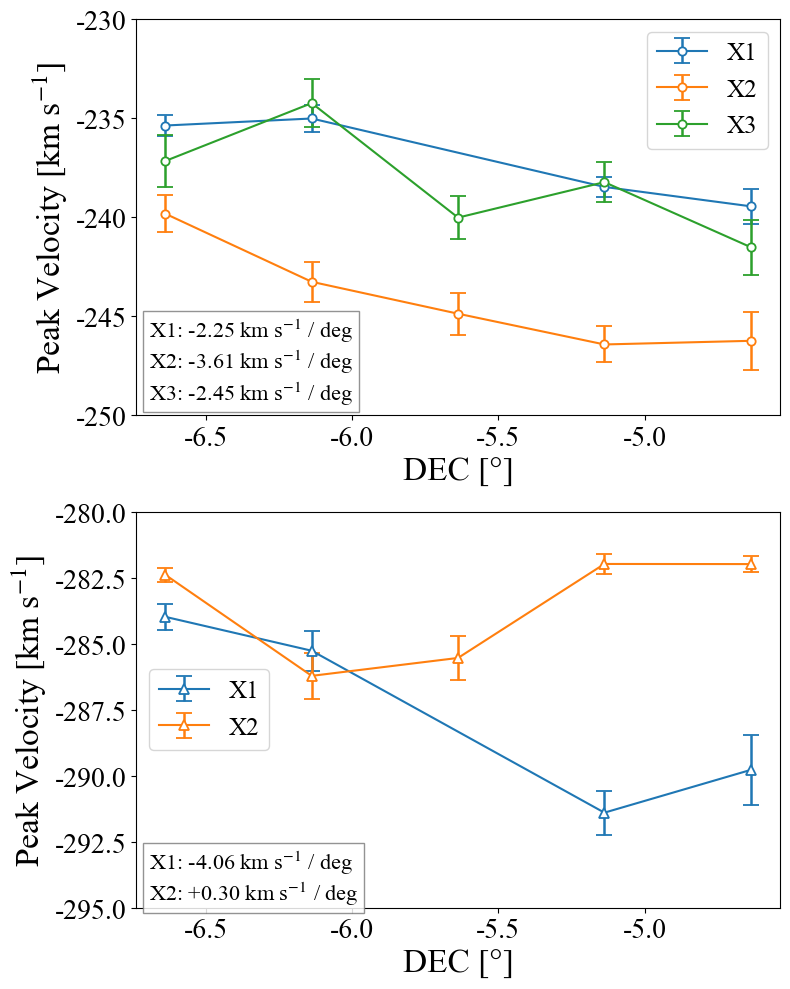

In [29]:

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix' 


# =========================
# 1. Read the txt file.
# =========================
txt_file = "./PV_path_peak_velocity.txt"
df = pd.read_csv(txt_file, sep="\t")

print(df.columns)
print(df.head())

# =========================
# 2. Color settings.
# =========================
path_colors = {
    "X1": "tab:blue",
    "X2": "tab:orange",
    "X3": "tab:green"
}
default_color = "black"

# =========================
# 3. Define the fitting function.
# =========================
def weighted_linear_fit(x, y, yerr=None):
    """Fit a straight line with optional inverse-uncertainty weights.

        Parameters
        ----------
        x, y : array-like
            Independent and dependent data values.
        yerr : array-like, optional
            Positive one-sigma uncertainties for ``y``. Invalid rows are removed.

        Returns
        -------
        slope : float
            Best-fitting coefficient of ``x``, or NaN when fewer than two points remain.
        intercept : float
            Best-fitting constant term, or NaN when the fit is underdetermined."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    if yerr is not None:
        yerr = np.asarray(yerr, dtype=float)
        mask &= np.isfinite(yerr) & (yerr > 0)

    x = x[mask]
    y = y[mask]

    if yerr is not None:
        yerr = yerr[mask]

    # At least two points are required.
    if len(x) < 2:
        return np.nan, np.nan

    # Use weighted fitting if uncertainties are provided.
    if yerr is not None and len(yerr) == len(x):
        coeff = np.polyfit(x, y, 1, w=1.0 / yerr)
    else:
        coeff = np.polyfit(x, y, 1)

    a, b = coeff[0], coeff[1]
    return a, b


# =========================
# 4. Create upper and lower subplots.
# =========================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=False, sharey=False)

# Store slope annotation text.
slope_text_240 = []
slope_text_280 = []

# =========================
# 5. Loop over plotting and fitting.
# =========================
for path_name in ["X1", "X2", "X3"]:
    sub = df[df["Path"] == path_name].copy()

    if len(sub) == 0:
        continue

    sub = sub.sort_values("DEC_center_deg")
    color = path_colors.get(path_name, default_color)

    # -------------------------
    # Upper panel: 240 km/s component.
    # -------------------------
    sub240 = sub[["DEC_center_deg", "V_mean_240_kms", "V_err_240_kms"]].dropna()

    if len(sub240) > 1:
        x240 = sub240["DEC_center_deg"].values
        y240 = sub240["V_mean_240_kms"].values
        yerr240 = sub240["V_err_240_kms"].values

        # Raw data with error bars.
        ax1.errorbar(
            x240, y240, yerr=yerr240,
            fmt="o-",
            color=color,
            ecolor=color,
            capsize=6,
            capthick=1.8,
            elinewidth=1.8,
            markersize=6,
            markerfacecolor="white",
            markeredgewidth=1.3,
            linewidth=1.5,
            label=path_name
        )

        # Fit.
        a240, b240 = weighted_linear_fit(x240, y240, yerr240)

        # Draw the fitted line.
        if np.isfinite(a240):
            xfit = np.linspace(np.nanmin(x240), np.nanmax(x240), 200)
            yfit = a240 * xfit + b240
            # ax1.plot(xfit, yfit, "--", color=color, linewidth=2)

            slope_text_240.append(
                f"{path_name}: {a240:+.2f} km s$^{{-1}}$ / deg"
            )

    # -------------------------
    # Lower panel: 280 km/s component.
    # -------------------------
    sub280 = sub[["DEC_center_deg", "V_mean_280_kms", "V_err_280_kms"]].dropna()

    if len(sub280) > 1:
        x280 = sub280["DEC_center_deg"].values
        y280 = sub280["V_mean_280_kms"].values
        yerr280 = sub280["V_err_280_kms"].values

        # Raw data with error bars.
        ax2.errorbar(
            x280, y280, yerr=yerr280,
            fmt="^-",
            color=color,
            ecolor=color,
            capsize=6,
            capthick=1.8,
            elinewidth=1.8,
            markersize=7,
            markerfacecolor="white",
            markeredgewidth=1.3,
            linewidth=1.5,
            label=path_name
        )

        # Fit.
        a280, b280 = weighted_linear_fit(x280, y280, yerr280)

        # Draw the fitted line.
        if np.isfinite(a280):
            xfit = np.linspace(np.nanmin(x280), np.nanmax(x280), 200)
            yfit = a280 * xfit + b280
            # ax2.plot(xfit, yfit, "--", color=color, linewidth=2)

            slope_text_280.append(
                f"{path_name}: {a280:+.2f} km s$^{{-1}}$ / deg"
            )

# =========================
# 6. Upper-panel settings for 240 km/s.
# =========================
ax1.set_xlabel("DEC [°]", fontsize=24)
ax1.set_ylabel("Peak Velocity [km s$^{-1}$]", fontsize=24)
# ax1.set_title("Peak Velocity vs DEC", fontsize=18)
ax1.set_ylim(-250, -230)
# ax1.grid(True, alpha=0.3)
ax1.tick_params(labelsize=20)
ax1.legend(fontsize=18)

# Annotate the slope.
ax1.text(
    0.02, 0.25,
    "\n".join(slope_text_240),
    transform=ax1.transAxes,
    fontsize=16,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85)
)

# =========================
# 7. Lower-panel settings for 280 km/s.
# =========================
ax2.set_xlabel("DEC [°]", fontsize=24)
ax2.set_ylabel("Peak Velocity [km s$^{-1}$]", fontsize=24)
# ax2.set_title("~280 km/s Component", fontsize=15)
ax2.set_ylim(-295, -280)
# ax2.set_xlim(-6.75, -6.0)
# ax2.grid(True, alpha=0.3)
ax2.tick_params(labelsize=20)
ax2.legend(fontsize=18)

# Annotate the slope.
ax2.text(
    0.02, 0.15,
    "\n".join(slope_text_280),
    transform=ax2.transAxes,
    fontsize=16,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85)
)

# =========================
# 8. Layout.
# =========================
plt.tight_layout()

plt.savefig("./peak_velocity_trends.pdf", dpi=300, bbox_inches="tight")
plt.show()
